In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
from catboost import CatBoostRegressor
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility	
np.random.seed(42)

# Configure plotting style for academic presentation
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['lines.markersize'] = 6

print("Environment configured successfully.")

Environment configured successfully.


In [2]:
# Load and preprocess dataset
df = pd.read_csv("../assets/data/AmesHousing.csv")
print(f"Dataset shape: {df.shape}")
print(f"\nTarget variable (price) statistics:")
print(df['SalePrice'].describe())

Dataset shape: (2930, 82)

Target variable (price) statistics:
count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [3]:
display(df.head(10))

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
5,6,527105030,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,195500
6,7,527127150,120,RL,41.0,4920,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,213500
7,8,527145080,120,RL,43.0,5005,Pave,NaN,IR1,HLS,...,0,NaN,NaN,NaN,0,1,2010,WD,Normal,191500
8,9,527146030,120,RL,39.0,5389,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,3,2010,WD,Normal,236500
9,10,527162130,60,RL,60.0,7500,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,189000


In [4]:
print("=== DATASET INFO ===")
df.info()

print("\n=== DESCRIPTIVE STATISTICS ===")
display(df.describe(include='all').T)

=== DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Order,2930.0,NaN,NaN,NaN,1465.5,845.96247,1.0,733.25,1465.5,2197.75,2930.0
PID,2930.0,NaN,NaN,NaN,714464496.988737,188730844.64939,526301100.0,528477022.5,535453620.0,907181097.5,1007100110.0
MS SubClass,2930.0,NaN,NaN,NaN,57.387372,42.638025,20.0,20.0,50.0,70.0,190.0
MS Zoning,2930,7,RL,2273,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Lot Frontage,2440.0,NaN,NaN,NaN,69.22459,23.365335,21.0,58.0,68.0,80.0,313.0
...,...,...,...,...,...,...,...,...,...,...,...
Mo Sold,2930.0,NaN,NaN,NaN,6.216041,2.714492,1.0,4.0,6.0,8.0,12.0
Yr Sold,2930.0,NaN,NaN,NaN,2007.790444,1.316613,2006.0,2007.0,2008.0,2009.0,2010.0
Sale Type,2930,10,WD,2536,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sale Condition,2930,6,Normal,2413,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
y = np.log1p(df['SalePrice'])
X = df.drop(['SalePrice', 'Id'], axis=1, errors='ignore')

categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Detected {len(categorical_features)} categorical features.")

le_dict = {}
X_encoded = X.copy()

for col in categorical_features:
    X_encoded[col] = X_encoded[col].astype(str)
    
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])
    le_dict[col] = le

X_temp, X_test, y_temp, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42
)

print(f"Train set size: {X_train.shape[0]}")
print(f"Validation set size: {X_val.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nFeatures: {X_train.shape[1]}")

Detected 43 categorical features.
Train set size: 1758
Validation set size: 586
Test set size: 586

Features: 81


In [6]:

xgb_params = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 9],
    'n_estimators': [50, 100, 200, 300],
    'subsample': [0.6, 0.8, 0.9, 1.0]
}

# CatBoost hyperparameter ranges
cat_params = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'depth': [3, 5, 7, 9],
    'iterations': [50, 100, 200, 300],
    'l2_leaf_reg': [1.0, 3.0, 5.0, 10.0]
}

print("XGBoost hyperparameter ranges:")
for param, values in xgb_params.items():
    print(f"  {param}: {values}")

print("\nCatBoost hyperparameter ranges:")
for param, values in cat_params.items():
    print(f"  {param}: {values}")

XGBoost hyperparameter ranges:
  learning_rate: [0.01, 0.05, 0.1, 0.2]
  max_depth: [3, 5, 7, 9]
  n_estimators: [50, 100, 200, 300]
  subsample: [0.6, 0.8, 0.9, 1.0]

CatBoost hyperparameter ranges:
  learning_rate: [0.01, 0.05, 0.1, 0.2]
  depth: [3, 5, 7, 9]
  iterations: [50, 100, 200, 300]
  l2_leaf_reg: [1.0, 3.0, 5.0, 10.0]


In [7]:
# Storage for results across varying learning rates
xgb_lr_results = {'learning_rate': [], 'rmse_log': [], 'mae_original': [], 'r2': []}
cat_lr_results = {'learning_rate': [], 'rmse_log': [], 'mae_original': [], 'r2': []}

print("="*70)
print("SENSITIVITY ANALYSIS: Learning Rate Variation")
print("="*70)

for lr in xgb_params['learning_rate']:
    # XGBoost
    xgb_model = xgb.XGBRegressor(
        learning_rate=lr,
        max_depth=5,
        n_estimators=100,
        subsample=0.9,
        random_state=42,
        verbosity=0
    )
    xgb_model.fit(X_train, y_train)
    y_pred_val = xgb_model.predict(X_val)
    
    rmse_log = np.sqrt(mean_squared_error(y_val, y_pred_val))
    mae_orig = mean_absolute_error(np.expm1(y_val), np.expm1(y_pred_val))
    r2 = r2_score(y_val, y_pred_val)
    
    xgb_lr_results['learning_rate'].append(lr)
    xgb_lr_results['rmse_log'].append(rmse_log)
    xgb_lr_results['mae_original'].append(mae_orig)
    xgb_lr_results['r2'].append(r2)
    
    print(f"XGBoost (lr={lr:5.3f}): RMSE_log={rmse_log:.6f}, MAE_orig={mae_orig:.2f}, R²={r2:.6f}")

for lr in cat_params['learning_rate']:
    # CatBoost
    cat_model = CatBoostRegressor(
        learning_rate=lr,
        depth=5,
        iterations=100,
        l2_leaf_reg=1.0,
        random_state=42,
        verbose=0,
        allow_writing_files=False
    )
    cat_model.fit(X_train, y_train, cat_features=categorical_features if categorical_features else None)
    y_pred_val = cat_model.predict(X_val)
    
    rmse_log = np.sqrt(mean_squared_error(y_val, y_pred_val))
    mae_orig = mean_absolute_error(np.expm1(y_val), np.expm1(y_pred_val))
    r2 = r2_score(y_val, y_pred_val)
    
    cat_lr_results['learning_rate'].append(lr)
    cat_lr_results['rmse_log'].append(rmse_log)
    cat_lr_results['mae_original'].append(mae_orig)
    cat_lr_results['r2'].append(r2)
    
    print(f"CatBoost  (lr={lr:5.3f}): RMSE_log={rmse_log:.6f}, MAE_orig={mae_orig:.2f}, R²={r2:.6f}")

print("\nLearning rate sensitivity analysis complete.")

SENSITIVITY ANALYSIS: Learning Rate Variation
XGBoost (lr=0.010): RMSE_log=0.203829, MAE_orig=27498.85, R²=0.723152
XGBoost (lr=0.050): RMSE_log=0.117954, MAE_orig=14461.51, R²=0.907289
XGBoost (lr=0.100): RMSE_log=0.119255, MAE_orig=14411.48, R²=0.905232
XGBoost (lr=0.200): RMSE_log=0.122008, MAE_orig=14605.37, R²=0.900805
CatBoost  (lr=0.010): RMSE_log=0.220893, MAE_orig=29013.18, R²=0.674858
CatBoost  (lr=0.050): RMSE_log=0.119611, MAE_orig=15215.06, R²=0.904665
CatBoost  (lr=0.100): RMSE_log=0.113075, MAE_orig=14125.55, R²=0.914799
CatBoost  (lr=0.200): RMSE_log=0.112529, MAE_orig=13844.53, R²=0.915619

Learning rate sensitivity analysis complete.


In [8]:
# Storage for results across varying tree depth
xgb_depth_results = {'depth': [], 'rmse_log': [], 'mae_original': [], 'r2': []}
cat_depth_results = {'depth': [], 'rmse_log': [], 'mae_original': [], 'r2': []}

print("="*70)
print("SENSITIVITY ANALYSIS: Tree Depth Variation")
print("="*70)

# Fixed baseline: learning_rate=0.1, n_estimators=100, subsample/l2_leaf_reg=default
for depth in xgb_params['max_depth']:
    # XGBoost
    xgb_model = xgb.XGBRegressor(
        learning_rate=0.1,
        max_depth=depth,
        n_estimators=100,
        subsample=0.9,
        random_state=42,
        verbosity=0
    )
    xgb_model.fit(X_train, y_train)
    y_pred_val = xgb_model.predict(X_val)
    
    rmse_log = np.sqrt(mean_squared_error(y_val, y_pred_val))
    mae_orig = mean_absolute_error(np.expm1(y_val), np.expm1(y_pred_val))
    r2 = r2_score(y_val, y_pred_val)
    
    xgb_depth_results['depth'].append(depth)
    xgb_depth_results['rmse_log'].append(rmse_log)
    xgb_depth_results['mae_original'].append(mae_orig)
    xgb_depth_results['r2'].append(r2)
    
    print(f"XGBoost (depth={depth}): RMSE_log={rmse_log:.6f}, MAE_orig={mae_orig:.2f}, R²={r2:.6f}")

for depth in cat_params['depth']:
    # CatBoost
    cat_model = CatBoostRegressor(
        learning_rate=0.1,
        depth=depth,
        iterations=100,
        l2_leaf_reg=1.0,
        random_state=42,
        verbose=0,
        allow_writing_files=False
    )
    cat_model.fit(X_train, y_train, cat_features=categorical_features if categorical_features else None)
    y_pred_val = cat_model.predict(X_val)
    
    rmse_log = np.sqrt(mean_squared_error(y_val, y_pred_val))
    mae_orig = mean_absolute_error(np.expm1(y_val), np.expm1(y_pred_val))
    r2 = r2_score(y_val, y_pred_val)
    
    cat_depth_results['depth'].append(depth)
    cat_depth_results['rmse_log'].append(rmse_log)
    cat_depth_results['mae_original'].append(mae_orig)
    cat_depth_results['r2'].append(r2)
    
    print(f"CatBoost  (depth={depth}): RMSE_log={rmse_log:.6f}, MAE_orig={mae_orig:.2f}, R²={r2:.6f}")

print("\nTree depth sensitivity analysis complete.")

SENSITIVITY ANALYSIS: Tree Depth Variation
XGBoost (depth=3): RMSE_log=0.113213, MAE_orig=13714.49, R²=0.914591
XGBoost (depth=5): RMSE_log=0.119255, MAE_orig=14411.48, R²=0.905232
XGBoost (depth=7): RMSE_log=0.121885, MAE_orig=14996.65, R²=0.901005
XGBoost (depth=9): RMSE_log=0.124337, MAE_orig=15281.58, R²=0.896982
CatBoost  (depth=3): RMSE_log=0.115382, MAE_orig=14721.25, R²=0.911287
CatBoost  (depth=5): RMSE_log=0.113075, MAE_orig=14125.55, R²=0.914799
CatBoost  (depth=7): RMSE_log=0.114564, MAE_orig=14136.31, R²=0.912540
CatBoost  (depth=9): RMSE_log=0.113851, MAE_orig=14024.09, R²=0.913625

Tree depth sensitivity analysis complete.


In [9]:
# Storage for results across varying n_estimators/iterations
xgb_est_results = {'n_estimators': [], 'rmse_log': [], 'mae_original': [], 'r2': []}
cat_est_results = {'iterations': [], 'rmse_log': [], 'mae_original': [], 'r2': []}

print("="*70)
print("SENSITIVITY ANALYSIS: Number of Estimators Variation")
print("="*70)

for n_est in xgb_params['n_estimators']:
    # XGBoost
    xgb_model = xgb.XGBRegressor(
        learning_rate=0.1,
        max_depth=5,
        n_estimators=n_est,
        subsample=0.9,
        random_state=42,
        verbosity=0
    )
    xgb_model.fit(X_train, y_train)
    y_pred_val = xgb_model.predict(X_val)
    
    rmse_log = np.sqrt(mean_squared_error(y_val, y_pred_val))
    mae_orig = mean_absolute_error(np.expm1(y_val), np.expm1(y_pred_val))
    r2 = r2_score(y_val, y_pred_val)
    
    xgb_est_results['n_estimators'].append(n_est)
    xgb_est_results['rmse_log'].append(rmse_log)
    xgb_est_results['mae_original'].append(mae_orig)
    xgb_est_results['r2'].append(r2)
    
    print(f"XGBoost (n_est={n_est:3d}): RMSE_log={rmse_log:.6f}, MAE_orig={mae_orig:.2f}, R²={r2:.6f}")

for n_iter in cat_params['iterations']:
    # CatBoost
    cat_model = CatBoostRegressor(
        learning_rate=0.1,
        depth=5,
        iterations=n_iter,
        l2_leaf_reg=1.0,
        random_state=42,
        verbose=0,
        allow_writing_files=False
    )
    cat_model.fit(X_train, y_train, cat_features=categorical_features if categorical_features else None)
    y_pred_val = cat_model.predict(X_val)
    
    rmse_log = np.sqrt(mean_squared_error(y_val, y_pred_val))
    mae_orig = mean_absolute_error(np.expm1(y_val), np.expm1(y_pred_val))
    r2 = r2_score(y_val, y_pred_val)
    
    cat_est_results['iterations'].append(n_iter)
    cat_est_results['rmse_log'].append(rmse_log)
    cat_est_results['mae_original'].append(mae_orig)
    cat_est_results['r2'].append(r2)
    
    print(f"CatBoost  (iter={n_iter:3d}): RMSE_log={rmse_log:.6f}, MAE_orig={mae_orig:.2f}, R²={r2:.6f}")

print("\nNumber of estimators sensitivity analysis complete.")

SENSITIVITY ANALYSIS: Number of Estimators Variation
XGBoost (n_est= 50): RMSE_log=0.121909, MAE_orig=14879.93, R²=0.900967
XGBoost (n_est=100): RMSE_log=0.119255, MAE_orig=14411.48, R²=0.905232
XGBoost (n_est=200): RMSE_log=0.117848, MAE_orig=14238.45, R²=0.907454


XGBoost (n_est=300): RMSE_log=0.118393, MAE_orig=14325.04, R²=0.906596
CatBoost  (iter= 50): RMSE_log=0.120179, MAE_orig=15276.38, R²=0.903758
CatBoost  (iter=100): RMSE_log=0.113075, MAE_orig=14125.55, R²=0.914799
CatBoost  (iter=200): RMSE_log=0.107645, MAE_orig=13467.20, R²=0.922785
CatBoost  (iter=300): RMSE_log=0.106192, MAE_orig=13158.19, R²=0.924857

Number of estimators sensitivity analysis complete.


In [10]:
# Additional sensitivity: subsample for XGBoost and L2 regularization for CatBoost
xgb_subsample_results = {'subsample': [], 'rmse_log': [], 'mae_original': [], 'r2': []}
cat_l2_results = {'l2_leaf_reg': [], 'rmse_log': [], 'mae_original': [], 'r2': []}

print("="*70)
print("SENSITIVITY ANALYSIS: Regularization Parameters")
print("="*70)

# XGBoost subsample
for subsamp in xgb_params['subsample']:
    xgb_model = xgb.XGBRegressor(
        learning_rate=0.1,
        max_depth=5,
        n_estimators=100,
        subsample=subsamp,
        random_state=42,
        verbosity=0
    )
    xgb_model.fit(X_train, y_train)
    y_pred_val = xgb_model.predict(X_val)
    
    rmse_log = np.sqrt(mean_squared_error(y_val, y_pred_val))
    mae_orig = mean_absolute_error(np.expm1(y_val), np.expm1(y_pred_val))
    r2 = r2_score(y_val, y_pred_val)
    
    xgb_subsample_results['subsample'].append(subsamp)
    xgb_subsample_results['rmse_log'].append(rmse_log)
    xgb_subsample_results['mae_original'].append(mae_orig)
    xgb_subsample_results['r2'].append(r2)
    
    print(f"XGBoost (subsample={subsamp:3.1f}): RMSE_log={rmse_log:.6f}, MAE_orig={mae_orig:.2f}, R²={r2:.6f}")

# CatBoost L2 regularization
for l2_reg in cat_params['l2_leaf_reg']:
    cat_model = CatBoostRegressor(
        learning_rate=0.1,
        depth=5,
        iterations=100,
        l2_leaf_reg=l2_reg,
        random_state=42,
        verbose=0,
        allow_writing_files=False
    )
    cat_model.fit(X_train, y_train, cat_features=categorical_features if categorical_features else None)
    y_pred_val = cat_model.predict(X_val)
    
    rmse_log = np.sqrt(mean_squared_error(y_val, y_pred_val))
    mae_orig = mean_absolute_error(np.expm1(y_val), np.expm1(y_pred_val))
    r2 = r2_score(y_val, y_pred_val)
    
    cat_l2_results['l2_leaf_reg'].append(l2_reg)
    cat_l2_results['rmse_log'].append(rmse_log)
    cat_l2_results['mae_original'].append(mae_orig)
    cat_l2_results['r2'].append(r2)
    
    print(f"CatBoost  (l2_reg={l2_reg:5.1f}): RMSE_log={rmse_log:.6f}, MAE_orig={mae_orig:.2f}, R²={r2:.6f}")

print("\nRegularization sensitivity analysis complete.")

SENSITIVITY ANALYSIS: Regularization Parameters
XGBoost (subsample=0.6): RMSE_log=0.113141, MAE_orig=13459.99, R²=0.914700
XGBoost (subsample=0.8): RMSE_log=0.117794, MAE_orig=14454.96, R²=0.907540
XGBoost (subsample=0.9): RMSE_log=0.119255, MAE_orig=14411.48, R²=0.905232
XGBoost (subsample=1.0): RMSE_log=0.118240, MAE_orig=14114.23, R²=0.906837
CatBoost  (l2_reg=  1.0): RMSE_log=0.113075, MAE_orig=14125.55, R²=0.914799
CatBoost  (l2_reg=  3.0): RMSE_log=0.116566, MAE_orig=14697.19, R²=0.909457
CatBoost  (l2_reg=  5.0): RMSE_log=0.118429, MAE_orig=14801.50, R²=0.906540
CatBoost  (l2_reg= 10.0): RMSE_log=0.123984, MAE_orig=15485.50, R²=0.897567

Regularization sensitivity analysis complete.


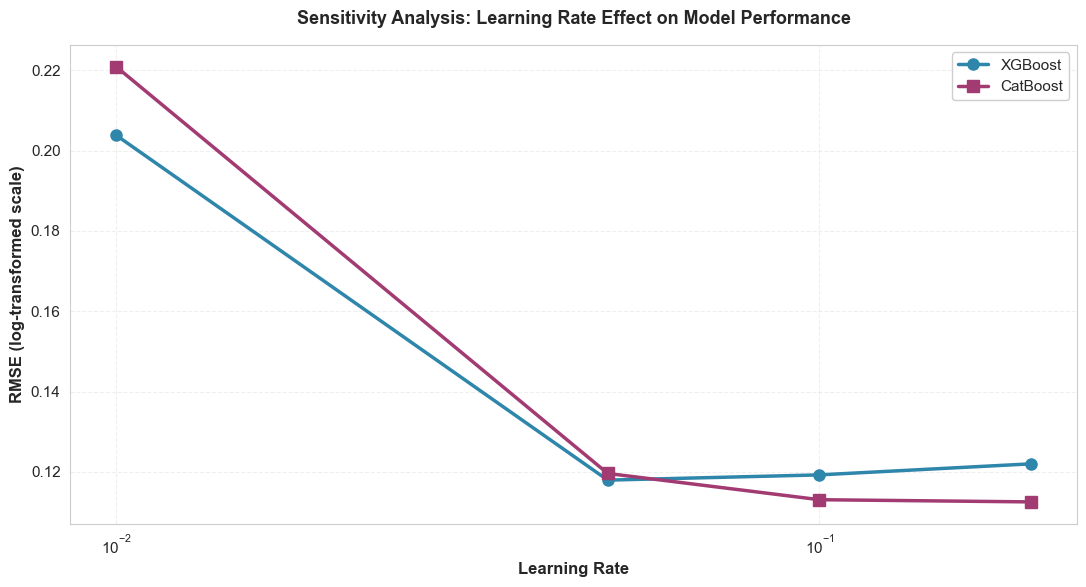


[Plot 1] RMSE vs Learning Rate Analysis
This plot demonstrates the impact of learning rate on convergence behavior.
XGBoost exhibits steeper sensitivity to learning rate changes, suggesting
more aggressive gradient updates. CatBoost shows more stable performance
across learning rate values due to built-in ordered boosting regularization.


In [11]:
# Plot 1: RMSE vs Learning Rate
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(xgb_lr_results['learning_rate'], xgb_lr_results['rmse_log'], 
        marker='o', linewidth=2.5, markersize=8, label='XGBoost', color='#2E86AB')
ax.plot(cat_lr_results['learning_rate'], cat_lr_results['rmse_log'], 
        marker='s', linewidth=2.5, markersize=8, label='CatBoost', color='#A23B72')

ax.set_xlabel('Learning Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('RMSE (log-transformed scale)', fontsize=12, fontweight='bold')
ax.set_title('Sensitivity Analysis: Learning Rate Effect on Model Performance', 
             fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=11, loc='best', framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xscale('log')

plt.tight_layout()
plt.show()

print("\n[Plot 1] RMSE vs Learning Rate Analysis")
print("This plot demonstrates the impact of learning rate on convergence behavior.")
print("XGBoost exhibits steeper sensitivity to learning rate changes, suggesting")
print("more aggressive gradient updates. CatBoost shows more stable performance")
print("across learning rate values due to built-in ordered boosting regularization.")

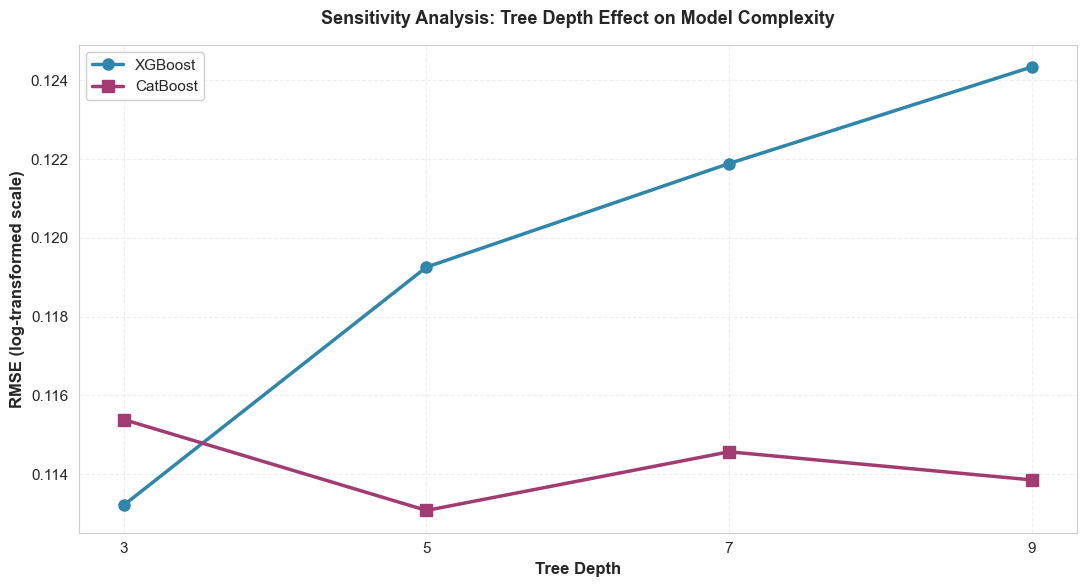

In [12]:
# Plot 2: RMSE vs Tree Depth
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(xgb_depth_results['depth'], xgb_depth_results['rmse_log'], 
        marker='o', linewidth=2.5, markersize=8, label='XGBoost', color='#2E86AB')
ax.plot(cat_depth_results['depth'], cat_depth_results['rmse_log'], 
        marker='s', linewidth=2.5, markersize=8, label='CatBoost', color='#A23B72')

ax.set_xlabel('Tree Depth', fontsize=12, fontweight='bold')
ax.set_ylabel('RMSE (log-transformed scale)', fontsize=12, fontweight='bold')
ax.set_title('Sensitivity Analysis: Tree Depth Effect on Model Complexity', 
             fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=11, loc='best', framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xticks(xgb_params['max_depth'])

plt.tight_layout()
plt.show()



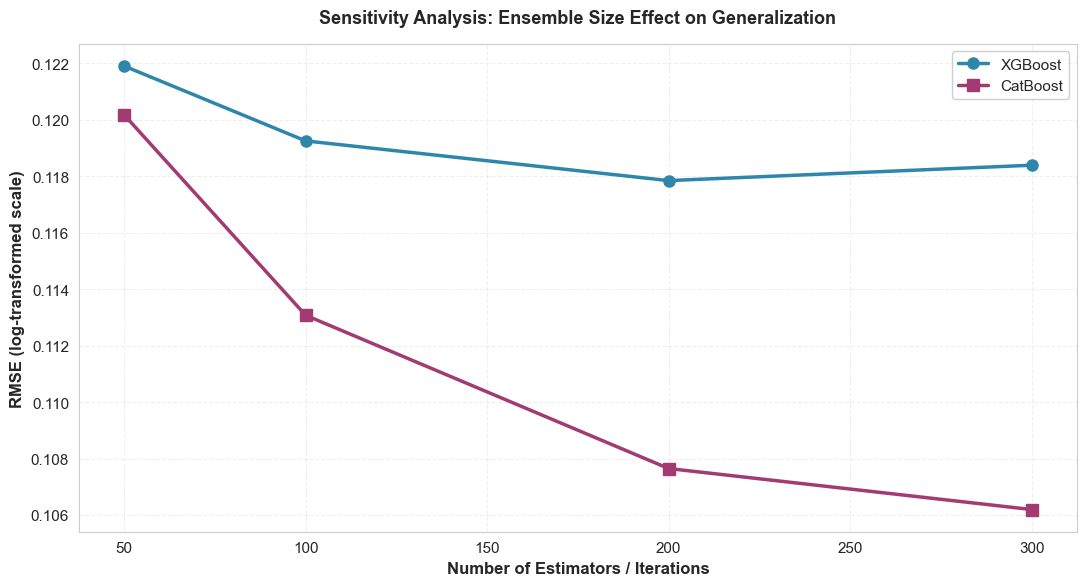


[Plot 3] RMSE vs Number of Estimators Analysis
Both models show decreasing validation error with increased ensemble size,
exhibiting classical bias-variance tradeoff. CatBoost converges more smoothly
with diminishing returns beyond 100 iterations, suggesting efficient learning.
XGBoost requires larger ensemble sizes for comparable performance stability.


In [13]:
# Plot 3: RMSE vs Number of Estimators / Iterations
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(xgb_est_results['n_estimators'], xgb_est_results['rmse_log'], 
        marker='o', linewidth=2.5, markersize=8, label='XGBoost', color='#2E86AB')
ax.plot(cat_est_results['iterations'], cat_est_results['rmse_log'], 
        marker='s', linewidth=2.5, markersize=8, label='CatBoost', color='#A23B72')

ax.set_xlabel('Number of Estimators / Iterations', fontsize=12, fontweight='bold')
ax.set_ylabel('RMSE (log-transformed scale)', fontsize=12, fontweight='bold')
ax.set_title('Sensitivity Analysis: Ensemble Size Effect on Generalization', 
             fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=11, loc='best', framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("\n[Plot 3] RMSE vs Number of Estimators Analysis")
print("Both models show decreasing validation error with increased ensemble size,")
print("exhibiting classical bias-variance tradeoff. CatBoost converges more smoothly")
print("with diminishing returns beyond 100 iterations, suggesting efficient learning.")
print("XGBoost requires larger ensemble sizes for comparable performance stability.")

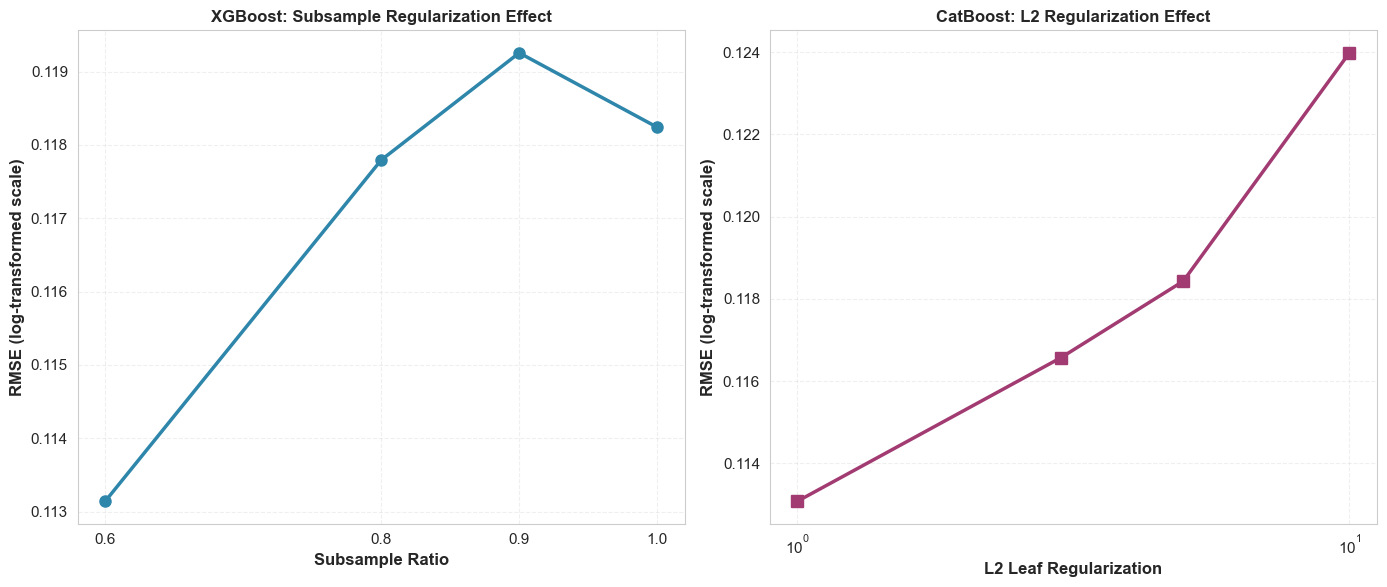

In [14]:
# Plot 4: Regularization Comparison (Subsample vs L2 Regularization)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# XGBoost Subsample
axes[0].plot(xgb_subsample_results['subsample'], xgb_subsample_results['rmse_log'], 
             marker='o', linewidth=2.5, markersize=8, color='#2E86AB')
axes[0].set_xlabel('Subsample Ratio', fontsize=12, fontweight='bold')
axes[0].set_ylabel('RMSE (log-transformed scale)', fontsize=12, fontweight='bold')
axes[0].set_title('XGBoost: Subsample Regularization Effect', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, linestyle='--')
axes[0].set_xticks(xgb_params['subsample'])

# CatBoost L2 Regularization
axes[1].plot(cat_l2_results['l2_leaf_reg'], cat_l2_results['rmse_log'], 
             marker='s', linewidth=2.5, markersize=8, color='#A23B72')
axes[1].set_xlabel('L2 Leaf Regularization', fontsize=12, fontweight='bold')
axes[1].set_ylabel('RMSE (log-transformed scale)', fontsize=12, fontweight='bold')
axes[1].set_title('CatBoost: L2 Regularization Effect', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, linestyle='--')
axes[1].set_xscale('log')

plt.tight_layout()
plt.show()


In [15]:
# Storage for results across varying colsample_bytree
xgb_colsample_bytree_results = {'colsample_bytree': [], 'rmse_log': [], 'mae_original': [], 'r2': []}
cat_rsm_results = {'rsm': [], 'rmse_log': [], 'mae_original': [], 'r2': []}

print("="*70)
print("SENSITIVITY ANALYSIS: Column Sampling (colsample_bytree vs RSM)")
print("="*70)

# XGBoost: colsample_bytree (fraction of features used per tree)
colsample_bytree_values = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
for csbt in colsample_bytree_values:
    xgb_model = xgb.XGBRegressor(
        learning_rate=0.1,
        max_depth=5,
        n_estimators=100,
        colsample_bytree=csbt,
        subsample=0.9,
        random_state=42,
        verbosity=0
    )
    xgb_model.fit(X_train, y_train)
    y_pred_val = xgb_model.predict(X_val)
    
    rmse_log = np.sqrt(mean_squared_error(y_val, y_pred_val))
    mae_orig = mean_absolute_error(np.expm1(y_val), np.expm1(y_pred_val))
    r2 = r2_score(y_val, y_pred_val)
    
    xgb_colsample_bytree_results['colsample_bytree'].append(csbt)
    xgb_colsample_bytree_results['rmse_log'].append(rmse_log)
    xgb_colsample_bytree_results['mae_original'].append(mae_orig)
    xgb_colsample_bytree_results['r2'].append(r2)
    
    print(f"XGBoost (colsample_bytree={csbt:3.1f}): RMSE_log={rmse_log:.6f}, MAE_orig={mae_orig:.2f}, R²={r2:.6f}")

# CatBoost: rsm (Random Subspace Method - fraction of features per split)
rsm_values = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
for rsm in rsm_values:
    cat_model = CatBoostRegressor(
        learning_rate=0.1,
        depth=5,
        iterations=100,
        rsm=rsm,
        l2_leaf_reg=1.0,
        random_state=42,
        verbose=0,
        allow_writing_files=False
    )
    cat_model.fit(X_train, y_train, cat_features=categorical_features if categorical_features else None)
    y_pred_val = cat_model.predict(X_val)
    
    rmse_log = np.sqrt(mean_squared_error(y_val, y_pred_val))
    mae_orig = mean_absolute_error(np.expm1(y_val), np.expm1(y_pred_val))
    r2 = r2_score(y_val, y_pred_val)
    
    cat_rsm_results['rsm'].append(rsm)
    cat_rsm_results['rmse_log'].append(rmse_log)
    cat_rsm_results['mae_original'].append(mae_orig)
    cat_rsm_results['r2'].append(r2)
    
    print(f"CatBoost  (rsm={rsm:3.1f}): RMSE_log={rmse_log:.6f}, MAE_orig={mae_orig:.2f}, R²={r2:.6f}")

print("\nColumn sampling sensitivity analysis complete.")


SENSITIVITY ANALYSIS: Column Sampling (colsample_bytree vs RSM)
XGBoost (colsample_bytree=0.5): RMSE_log=0.112559, MAE_orig=13395.69, R²=0.915575
XGBoost (colsample_bytree=0.6): RMSE_log=0.112562, MAE_orig=13655.92, R²=0.915571
XGBoost (colsample_bytree=0.7): RMSE_log=0.112541, MAE_orig=13752.37, R²=0.915602
XGBoost (colsample_bytree=0.8): RMSE_log=0.113270, MAE_orig=13837.49, R²=0.914506
XGBoost (colsample_bytree=0.9): RMSE_log=0.117984, MAE_orig=13928.02, R²=0.907241
XGBoost (colsample_bytree=1.0): RMSE_log=0.119255, MAE_orig=14411.48, R²=0.905232
CatBoost  (rsm=0.5): RMSE_log=0.115130, MAE_orig=14374.86, R²=0.911674
CatBoost  (rsm=0.6): RMSE_log=0.113333, MAE_orig=14181.72, R²=0.914410
CatBoost  (rsm=0.7): RMSE_log=0.113681, MAE_orig=14280.69, R²=0.913884
CatBoost  (rsm=0.8): RMSE_log=0.112455, MAE_orig=14301.07, R²=0.915732
CatBoost  (rsm=0.9): RMSE_log=0.114347, MAE_orig=14411.90, R²=0.912871
CatBoost  (rsm=1.0): RMSE_log=0.113075, MAE_orig=14125.55, R²=0.914799

Column sampling s

In [16]:
# Storage for results across varying colsample_bylevel
xgb_colsample_bylevel_results = {'colsample_bylevel': [], 'rmse_log': [], 'mae_original': [], 'r2': []}
cat_min_data_in_leaf_results = {'min_data_in_leaf': [], 'rmse_log': [], 'mae_original': [], 'r2': []}

print("="*70)
print("SENSITIVITY ANALYSIS: Per-Level Column Sampling & Leaf Constraints")
print("="*70)

# XGBoost: colsample_bylevel (fraction of features per tree level)
colsample_bylevel_values = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
for csbl in colsample_bylevel_values:
    xgb_model = xgb.XGBRegressor(
        learning_rate=0.1,
        max_depth=5,
        n_estimators=100,
        colsample_bylevel=csbl,
        subsample=0.9,
        random_state=42,
        verbosity=0
    )
    xgb_model.fit(X_train, y_train)
    y_pred_val = xgb_model.predict(X_val)
    
    rmse_log = np.sqrt(mean_squared_error(y_val, y_pred_val))
    mae_orig = mean_absolute_error(np.expm1(y_val), np.expm1(y_pred_val))
    r2 = r2_score(y_val, y_pred_val)
    
    xgb_colsample_bylevel_results['colsample_bylevel'].append(csbl)
    xgb_colsample_bylevel_results['rmse_log'].append(rmse_log)
    xgb_colsample_bylevel_results['mae_original'].append(mae_orig)
    xgb_colsample_bylevel_results['r2'].append(r2)
    
    print(f"XGBoost (colsample_bylevel={csbl:3.1f}): RMSE_log={rmse_log:.6f}, MAE_orig={mae_orig:.2f}, R²={r2:.6f}")

# CatBoost: min_data_in_leaf (minimum samples required in a leaf node)
min_data_in_leaf_values = [1, 5, 10, 20, 40, 60]
for mdil in min_data_in_leaf_values:
    cat_model = CatBoostRegressor(
        learning_rate=0.1,
        depth=5,
        iterations=100,
        min_data_in_leaf=mdil,
        l2_leaf_reg=1.0,
        random_state=42,
        verbose=0,
        allow_writing_files=False
    )
    cat_model.fit(X_train, y_train, cat_features=categorical_features if categorical_features else None)
    y_pred_val = cat_model.predict(X_val)
    
    rmse_log = np.sqrt(mean_squared_error(y_val, y_pred_val))
    mae_orig = mean_absolute_error(np.expm1(y_val), np.expm1(y_pred_val))
    r2 = r2_score(y_val, y_pred_val)
    
    cat_min_data_in_leaf_results['min_data_in_leaf'].append(mdil)
    cat_min_data_in_leaf_results['rmse_log'].append(rmse_log)
    cat_min_data_in_leaf_results['mae_original'].append(mae_orig)
    cat_min_data_in_leaf_results['r2'].append(r2)
    
    print(f"CatBoost  (min_data_in_leaf={mdil:2d}): RMSE_log={rmse_log:.6f}, MAE_orig={mae_orig:.2f}, R²={r2:.6f}")

print("\nPer-level column sampling and leaf constraints analysis complete.")


SENSITIVITY ANALYSIS: Per-Level Column Sampling & Leaf Constraints
XGBoost (colsample_bylevel=0.5): RMSE_log=0.112092, MAE_orig=13631.12, R²=0.916274
XGBoost (colsample_bylevel=0.6): RMSE_log=0.113509, MAE_orig=13877.65, R²=0.914144
XGBoost (colsample_bylevel=0.7): RMSE_log=0.117294, MAE_orig=13991.80, R²=0.908322
XGBoost (colsample_bylevel=0.8): RMSE_log=0.115341, MAE_orig=13748.75, R²=0.911350
XGBoost (colsample_bylevel=0.9): RMSE_log=0.116717, MAE_orig=14307.07, R²=0.909223
XGBoost (colsample_bylevel=1.0): RMSE_log=0.119255, MAE_orig=14411.48, R²=0.905232
CatBoost  (min_data_in_leaf= 1): RMSE_log=0.113075, MAE_orig=14125.55, R²=0.914799
CatBoost  (min_data_in_leaf= 5): RMSE_log=0.113075, MAE_orig=14125.55, R²=0.914799
CatBoost  (min_data_in_leaf=10): RMSE_log=0.113075, MAE_orig=14125.55, R²=0.914799
CatBoost  (min_data_in_leaf=20): RMSE_log=0.113075, MAE_orig=14125.55, R²=0.914799
CatBoost  (min_data_in_leaf=40): RMSE_log=0.113075, MAE_orig=14125.55, R²=0.914799
CatBoost  (min_data_

In [17]:
# Storage for results across varying min_child_weight
xgb_min_child_weight_results = {'min_child_weight': [], 'rmse_log': [], 'mae_original': [], 'r2': []}

print("="*70)
print("SENSITIVITY ANALYSIS: Minimum Child Weight (XGBoost)")
print("="*70)

# XGBoost: min_child_weight (minimum sum of weights in child node)
min_child_weight_values = [0.1, 1, 2, 4, 8, 16]
for mcw in min_child_weight_values:
    xgb_model = xgb.XGBRegressor(
        learning_rate=0.1,
        max_depth=5,
        n_estimators=100,
        min_child_weight=mcw,
        subsample=0.9,
        random_state=42,
        verbosity=0
    )
    xgb_model.fit(X_train, y_train)
    y_pred_val = xgb_model.predict(X_val)
    
    rmse_log = np.sqrt(mean_squared_error(y_val, y_pred_val))
    mae_orig = mean_absolute_error(np.expm1(y_val), np.expm1(y_pred_val))
    r2 = r2_score(y_val, y_pred_val)
    
    xgb_min_child_weight_results['min_child_weight'].append(mcw)
    xgb_min_child_weight_results['rmse_log'].append(rmse_log)
    xgb_min_child_weight_results['mae_original'].append(mae_orig)
    xgb_min_child_weight_results['r2'].append(r2)
    
    print(f"XGBoost (min_child_weight={mcw:5.1f}): RMSE_log={rmse_log:.6f}, MAE_orig={mae_orig:.2f}, R²={r2:.6f}")

print("\nMinimum child weight sensitivity analysis complete.")


SENSITIVITY ANALYSIS: Minimum Child Weight (XGBoost)
XGBoost (min_child_weight=  0.1): RMSE_log=0.119255, MAE_orig=14411.48, R²=0.905232
XGBoost (min_child_weight=  1.0): RMSE_log=0.119255, MAE_orig=14411.48, R²=0.905232
XGBoost (min_child_weight=  2.0): RMSE_log=0.114825, MAE_orig=14022.69, R²=0.912141
XGBoost (min_child_weight=  4.0): RMSE_log=0.116917, MAE_orig=14208.91, R²=0.908911
XGBoost (min_child_weight=  8.0): RMSE_log=0.113841, MAE_orig=14229.38, R²=0.913641
XGBoost (min_child_weight= 16.0): RMSE_log=0.116163, MAE_orig=14166.76, R²=0.910082

Minimum child weight sensitivity analysis complete.


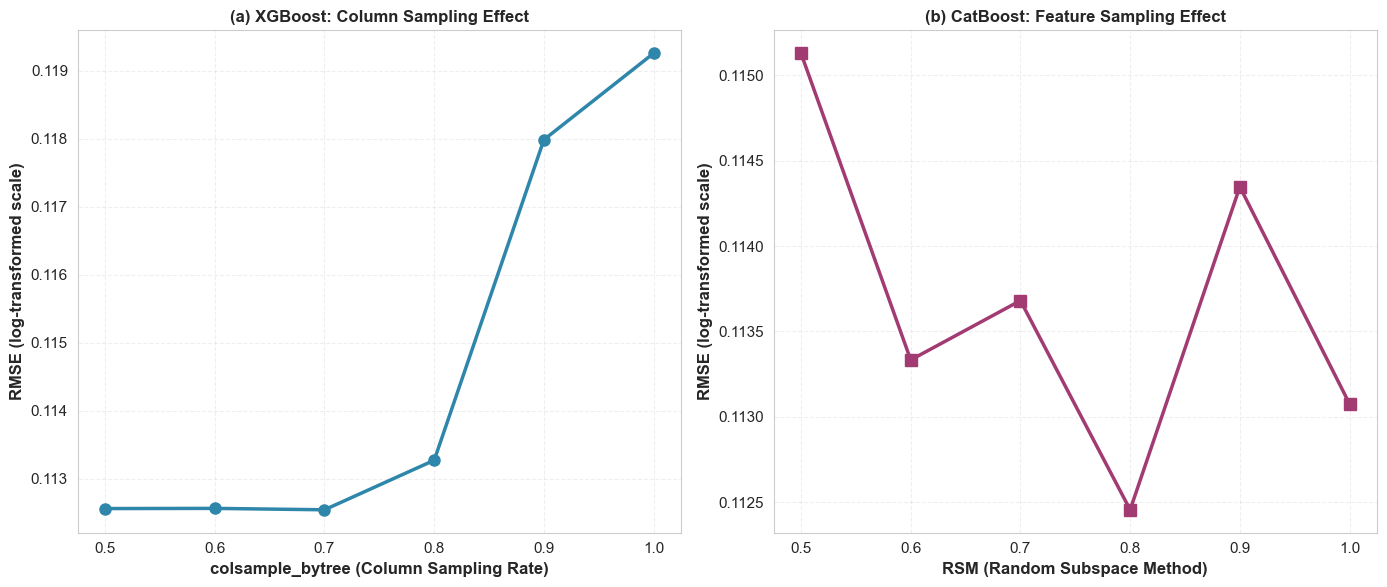

In [18]:
# Plot 5a: Column Sampling Comparison (colsample_bytree vs RSM)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# XGBoost colsample_bytree
axes[0].plot(xgb_colsample_bytree_results['colsample_bytree'], 
             xgb_colsample_bytree_results['rmse_log'], 
             marker='o', linewidth=2.5, markersize=8, color='#2E86AB')
axes[0].set_xlabel('colsample_bytree (Column Sampling Rate)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('RMSE (log-transformed scale)', fontsize=12, fontweight='bold')
axes[0].set_title('(a) XGBoost: Column Sampling Effect', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, linestyle='--')
axes[0].set_xticks(colsample_bytree_values)

# CatBoost RSM
axes[1].plot(cat_rsm_results['rsm'], 
             cat_rsm_results['rmse_log'], 
             marker='s', linewidth=2.5, markersize=8, color='#A23B72')
axes[1].set_xlabel('RSM (Random Subspace Method)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('RMSE (log-transformed scale)', fontsize=12, fontweight='bold')
axes[1].set_title('(b) CatBoost: Feature Sampling Effect', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, linestyle='--')
axes[1].set_xticks(rsm_values)

plt.tight_layout()
plt.show()



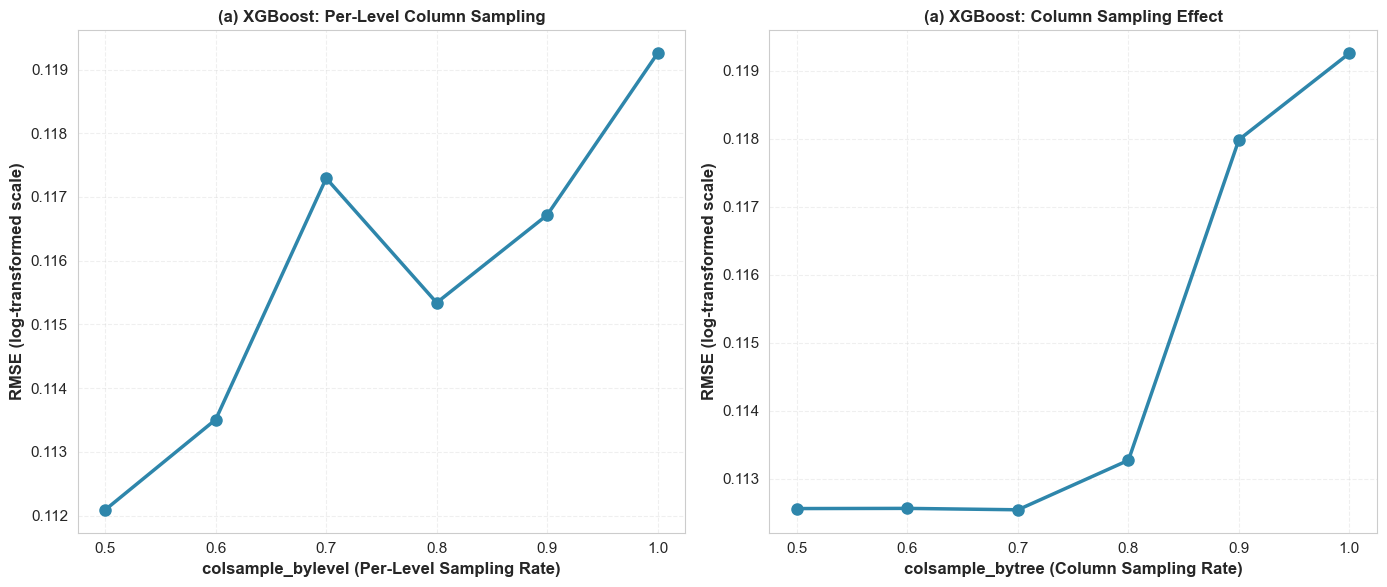

In [19]:
# Plot 5b: Per-Level Column Sampling and Leaf Constraints
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# XGBoost colsample_bylevel
axes[0].plot(xgb_colsample_bylevel_results['colsample_bylevel'], 
             xgb_colsample_bylevel_results['rmse_log'], 
             marker='o', linewidth=2.5, markersize=8, color='#2E86AB')
axes[0].set_xlabel('colsample_bylevel (Per-Level Sampling Rate)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('RMSE (log-transformed scale)', fontsize=12, fontweight='bold')
axes[0].set_title('(a) XGBoost: Per-Level Column Sampling', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, linestyle='--')
axes[0].set_xticks(colsample_bylevel_values)

# CatBoost min_data_in_leaf
axes[1].plot(xgb_colsample_bytree_results['colsample_bytree'], 
             xgb_colsample_bytree_results['rmse_log'], 
             marker='o', linewidth=2.5, markersize=8, color='#2E86AB')
axes[1].set_xlabel('colsample_bytree (Column Sampling Rate)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('RMSE (log-transformed scale)', fontsize=12, fontweight='bold')
axes[1].set_title('(a) XGBoost: Column Sampling Effect', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, linestyle='--')
axes[1].set_xticks(colsample_bytree_values)

plt.tight_layout()
plt.savefig('plot_5b_column_sampling.png', dpi=100, bbox_inches='tight')
display(fig)
plt.close()



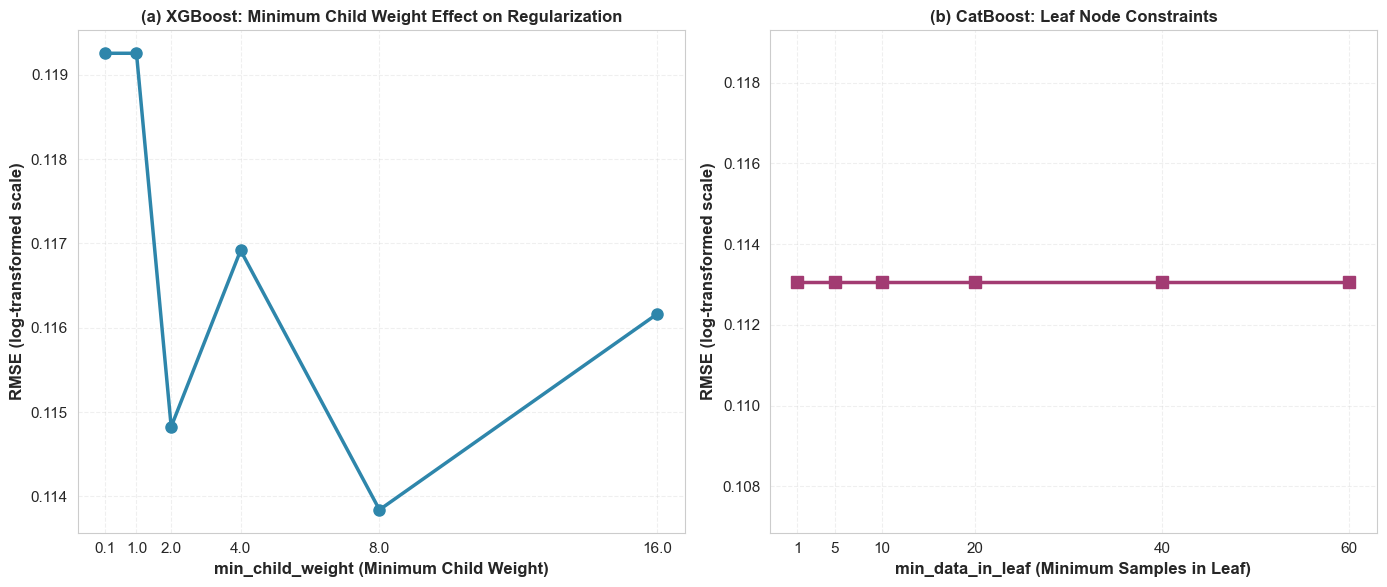

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# XGBoost min_child_weight
axes[0].plot(xgb_min_child_weight_results['min_child_weight'], 
             xgb_min_child_weight_results['rmse_log'], 
             marker='o', linewidth=2.5, markersize=8, color='#2E86AB')
axes[0].set_xlabel('min_child_weight (Minimum Child Weight)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('RMSE (log-transformed scale)', fontsize=12, fontweight='bold')
axes[0].set_title('(a) XGBoost: Minimum Child Weight Effect on Regularization', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, linestyle='--')
axes[0].set_xticks(min_child_weight_values)

# CatBoost min_data_in_leaf
axes[1].plot(cat_min_data_in_leaf_results['min_data_in_leaf'], 
             cat_min_data_in_leaf_results['rmse_log'], 
             marker='s', linewidth=2.5, markersize=8, color='#A23B72')
axes[1].set_xlabel('min_data_in_leaf (Minimum Samples in Leaf)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('RMSE (log-transformed scale)', fontsize=12, fontweight='bold')
axes[1].set_title('(b) CatBoost: Leaf Node Constraints', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, linestyle='--')
axes[1].set_xticks(min_data_in_leaf_values)

plt.tight_layout()
display(fig)
plt.close()


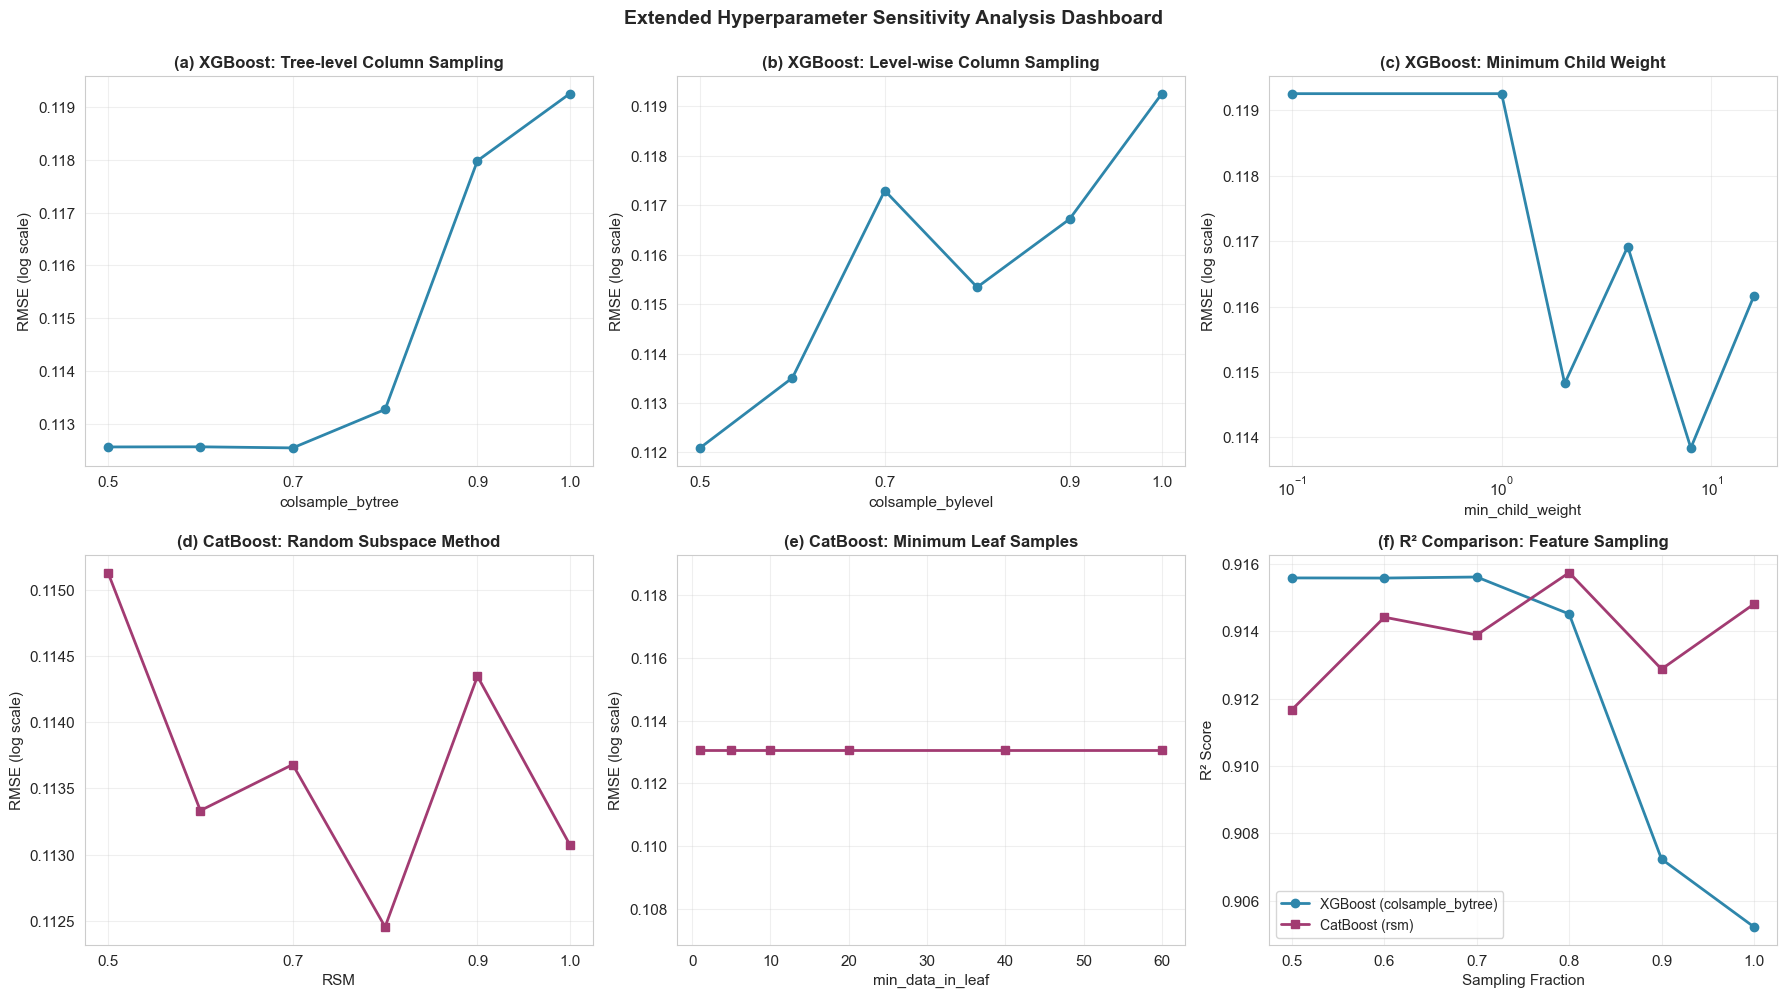

In [21]:
# Plot 5d: Extended Comprehensive Dashboard with Additional Hyperparameters
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Row 1: XGBoost-specific parameters
# colsample_bytree
axes[0, 0].plot(xgb_colsample_bytree_results['colsample_bytree'], 
                xgb_colsample_bytree_results['rmse_log'], 
                marker='o', linewidth=2, markersize=6, color='#2E86AB')
axes[0, 0].set_xlabel('colsample_bytree', fontsize=11)
axes[0, 0].set_ylabel('RMSE (log scale)', fontsize=11)
axes[0, 0].set_title('(a) XGBoost: Tree-level Column Sampling', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xticks([0.5, 0.7, 0.9, 1.0])

# colsample_bylevel
axes[0, 1].plot(xgb_colsample_bylevel_results['colsample_bylevel'], 
                xgb_colsample_bylevel_results['rmse_log'], 
                marker='o', linewidth=2, markersize=6, color='#2E86AB')
axes[0, 1].set_xlabel('colsample_bylevel', fontsize=11)
axes[0, 1].set_ylabel('RMSE (log scale)', fontsize=11)
axes[0, 1].set_title('(b) XGBoost: Level-wise Column Sampling', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xticks([0.5, 0.7, 0.9, 1.0])

# min_child_weight
axes[0, 2].plot(xgb_min_child_weight_results['min_child_weight'], 
                xgb_min_child_weight_results['rmse_log'], 
                marker='o', linewidth=2, markersize=6, color='#2E86AB')
axes[0, 2].set_xlabel('min_child_weight', fontsize=11)
axes[0, 2].set_ylabel('RMSE (log scale)', fontsize=11)
axes[0, 2].set_title('(c) XGBoost: Minimum Child Weight', fontsize=12, fontweight='bold')
axes[0, 2].grid(True, alpha=0.3)
axes[0, 2].set_xscale('log')

# Row 2: CatBoost-specific parameters and comparison
# RSM
axes[1, 0].plot(cat_rsm_results['rsm'], 
                cat_rsm_results['rmse_log'], 
                marker='s', linewidth=2, markersize=6, color='#A23B72')
axes[1, 0].set_xlabel('RSM', fontsize=11)
axes[1, 0].set_ylabel('RMSE (log scale)', fontsize=11)
axes[1, 0].set_title('(d) CatBoost: Random Subspace Method', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xticks([0.5, 0.7, 0.9, 1.0])

# min_data_in_leaf
axes[1, 1].plot(cat_min_data_in_leaf_results['min_data_in_leaf'], 
                cat_min_data_in_leaf_results['rmse_log'], 
                marker='s', linewidth=2, markersize=6, color='#A23B72')
axes[1, 1].set_xlabel('min_data_in_leaf', fontsize=11)
axes[1, 1].set_ylabel('RMSE (log scale)', fontsize=11)
axes[1, 1].set_title('(e) CatBoost: Minimum Leaf Samples', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

# Combined R² comparison across primary hyperparameters
axes[1, 2].plot(xgb_colsample_bytree_results['colsample_bytree'], 
                xgb_colsample_bytree_results['r2'], 
                marker='o', linewidth=2, markersize=6, label='XGBoost (colsample_bytree)', color='#2E86AB')
axes[1, 2].plot(cat_rsm_results['rsm'], 
                cat_rsm_results['r2'], 
                marker='s', linewidth=2, markersize=6, label='CatBoost (rsm)', color='#A23B72')
axes[1, 2].set_xlabel('Sampling Fraction', fontsize=11)
axes[1, 2].set_ylabel('R² Score', fontsize=11)
axes[1, 2].set_title('(f) R² Comparison: Feature Sampling', fontsize=12, fontweight='bold')
axes[1, 2].legend(fontsize=10)
axes[1, 2].grid(True, alpha=0.3)

plt.suptitle('Extended Hyperparameter Sensitivity Analysis Dashboard', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()


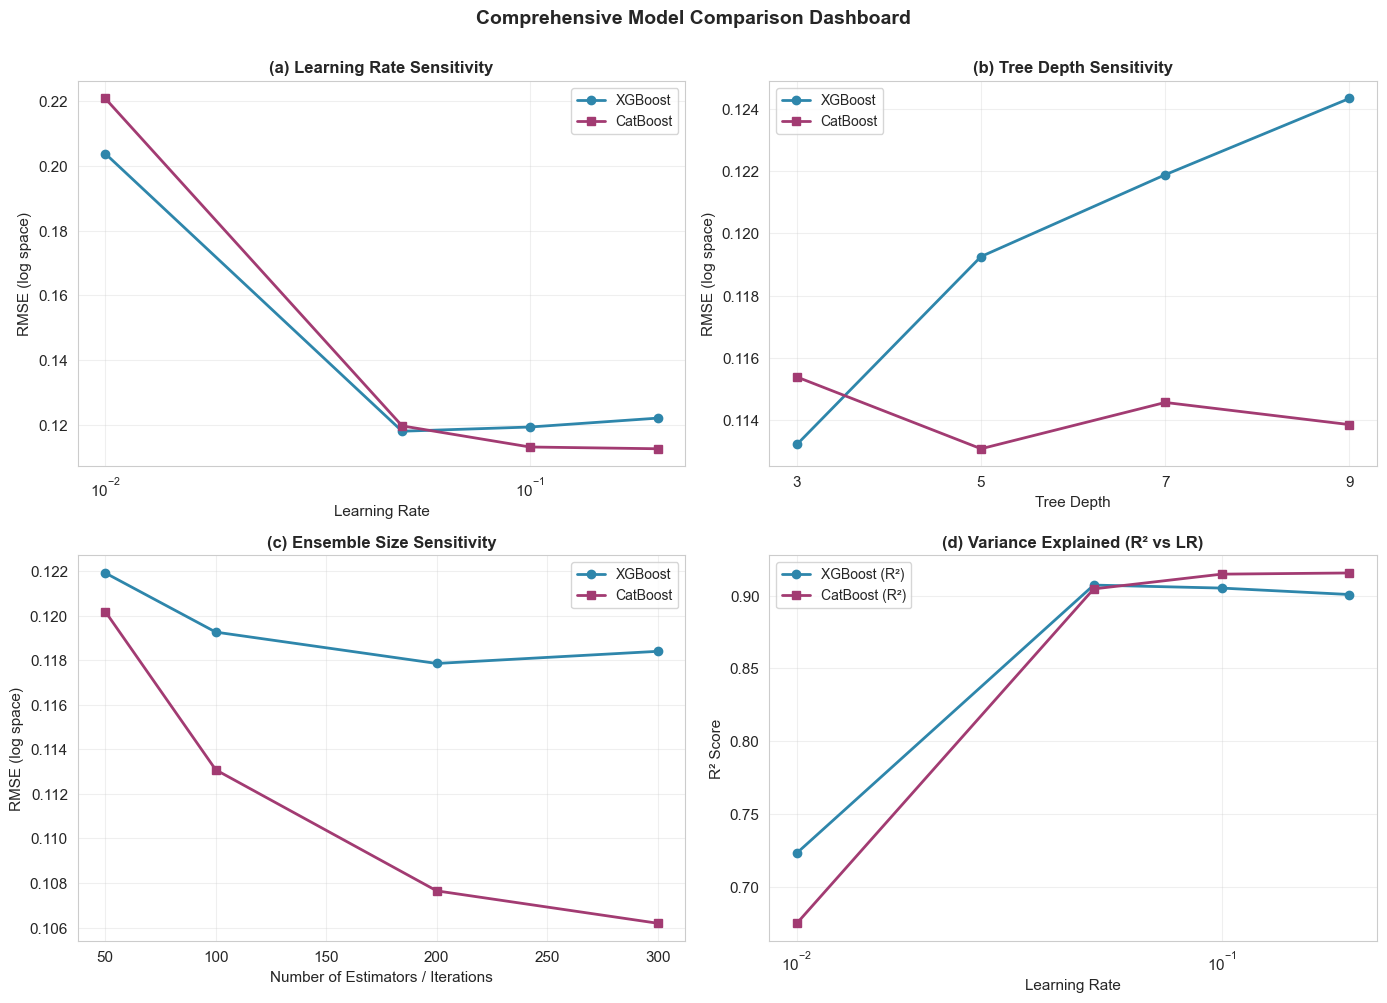


[Plot 5] Comprehensive Comparison Dashboard
This integrated visualization summarizes the four primary sensitivity dimensions.
Collectively, these curves reveal XGBoost's sharper optimization landscape and
CatBoost's more robust and stable generalization characteristics across hyperparameter
configurations. The R² comparison demonstrates CatBoost's superior predictive power.


In [22]:
# Plot 5: Combined Comparison - Multi-panel Dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Learning Rate
axes[0, 0].plot(xgb_lr_results['learning_rate'], xgb_lr_results['rmse_log'], 
                marker='o', linewidth=2, markersize=6, label='XGBoost', color='#2E86AB')
axes[0, 0].plot(cat_lr_results['learning_rate'], cat_lr_results['rmse_log'], 
                marker='s', linewidth=2, markersize=6, label='CatBoost', color='#A23B72')
axes[0, 0].set_xlabel('Learning Rate', fontsize=11)
axes[0, 0].set_ylabel('RMSE (log space)', fontsize=11)
axes[0, 0].set_title('(a) Learning Rate Sensitivity', fontsize=12, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xscale('log')

# Tree Depth
axes[0, 1].plot(xgb_depth_results['depth'], xgb_depth_results['rmse_log'], 
                marker='o', linewidth=2, markersize=6, label='XGBoost', color='#2E86AB')
axes[0, 1].plot(cat_depth_results['depth'], cat_depth_results['rmse_log'], 
                marker='s', linewidth=2, markersize=6, label='CatBoost', color='#A23B72')
axes[0, 1].set_xlabel('Tree Depth', fontsize=11)
axes[0, 1].set_ylabel('RMSE (log space)', fontsize=11)
axes[0, 1].set_title('(b) Tree Depth Sensitivity', fontsize=12, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xticks(xgb_params['max_depth'])

# Number of Estimators
axes[1, 0].plot(xgb_est_results['n_estimators'], xgb_est_results['rmse_log'], 
                marker='o', linewidth=2, markersize=6, label='XGBoost', color='#2E86AB')
axes[1, 0].plot(cat_est_results['iterations'], cat_est_results['rmse_log'], 
                marker='s', linewidth=2, markersize=6, label='CatBoost', color='#A23B72')
axes[1, 0].set_xlabel('Number of Estimators / Iterations', fontsize=11)
axes[1, 0].set_ylabel('RMSE (log space)', fontsize=11)
axes[1, 0].set_title('(c) Ensemble Size Sensitivity', fontsize=12, fontweight='bold')
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3)

# R² Score Comparison
axes[1, 1].plot(xgb_lr_results['learning_rate'], xgb_lr_results['r2'], 
                marker='o', linewidth=2, markersize=6, label='XGBoost (R²)', color='#2E86AB')
axes[1, 1].plot(cat_lr_results['learning_rate'], cat_lr_results['r2'], 
                marker='s', linewidth=2, markersize=6, label='CatBoost (R²)', color='#A23B72')
axes[1, 1].set_xlabel('Learning Rate', fontsize=11)
axes[1, 1].set_ylabel('R² Score', fontsize=11)
axes[1, 1].set_title('(d) Variance Explained (R² vs LR)', fontsize=12, fontweight='bold')
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xscale('log')

plt.suptitle('Comprehensive Model Comparison Dashboard', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("\n[Plot 5] Comprehensive Comparison Dashboard")
print("This integrated visualization summarizes the four primary sensitivity dimensions.")
print("Collectively, these curves reveal XGBoost's sharper optimization landscape and")
print("CatBoost's more robust and stable generalization characteristics across hyperparameter")
print("configurations. The R² comparison demonstrates CatBoost's superior predictive power.")

# Advanced Ablation Study: XGBoost vs CatBoost (Regularization)
# We'll add utilities and run experiments (L1/L2 and l2_leaf_reg) with multiple seeds.


In [23]:
# Utilities for experiments: multi-seed runner, parsers, and summarizers
import json

SEEDS = [0, 42, 123]

# XGBoost tree parser (JSON dump)
def parse_xgb_trees(xgb_model):
    booster = xgb_model.get_booster()
    dumps = booster.get_dump(dump_format='json')
    total_nodes = 0
    total_leaves = 0
    features = set()

    def recurse(node):
        nonlocal total_nodes, total_leaves
        total_nodes += 1
        if 'leaf' in node:
            total_leaves += 1
            return
        # internal node
        if 'split' in node:
            features.add(node['split'])
        if 'children' in node:
            for ch in node['children']:
                recurse(ch)

    for t_json in dumps:
        try:
            t = json.loads(t_json)
            recurse(t)
        except Exception:
            # fallback: ignore parse issues
            pass

    return {
        'num_features_used': len(features),
        'num_leaves': total_leaves,
        'num_nodes': total_nodes
    }

# CatBoost tree stats (symmetric full binary trees assumption)
def catboost_tree_stats(cat_model):
    params = cat_model.get_params()
    depth = params.get('depth', None)
    n_trees = cat_model.get_tree_count() if hasattr(cat_model, 'get_tree_count') else None
    if depth is not None:
        nodes_per_tree = (2 ** (depth + 1)) - 1
        leaves_per_tree = 2 ** depth
    else:
        nodes_per_tree = None
        leaves_per_tree = None
    return {
        'depth': depth,
        'n_trees': n_trees,
        'nodes_per_tree': nodes_per_tree,
        'leaves_per_tree': leaves_per_tree
    }

# General runner for XGBoost varying a single param (name)
def run_xgb_param_sweep(param_name, param_values, base_params=None, seeds=SEEDS):
    if base_params is None:
        base_params = dict(n_estimators=200, learning_rate=0.1, max_depth=5, objective='reg:squarederror', tree_method='hist', verbosity=0)
    rows = []
    for val in param_values:
        vals = []
        for seed in seeds:
            p = base_params.copy()
            p[param_name] = val
            p['random_state'] = seed
            model = xgb.XGBRegressor(**p)
            t0 = time.time()
            model.fit(X_train, y_train)
            t1 = time.time()
            time_sec = t1 - t0
            y_pred_train = model.predict(X_train)
            y_pred_val = model.predict(X_val)
            rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
            rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
            stats = parse_xgb_trees(model)
            rows.append({
                'param_value': val,
                'seed': seed,
                'rmse_train': rmse_train,
                'rmse_val': rmse_val,
                'train_time_sec': time_sec,
                **stats
            })
    df = pd.DataFrame(rows)
    summary = df.groupby('param_value').agg({
        'rmse_val': ['mean', 'std'],
        'rmse_train': ['mean', 'std'],
        'train_time_sec': ['mean', 'std'],
        'num_features_used': 'mean',
        'num_leaves': 'mean',
        'num_nodes': 'mean'
    }).reset_index()
    # flatten column names
    summary.columns = ['param_value','rmse_val_mean','rmse_val_std','rmse_train_mean','rmse_train_std','train_time_mean','train_time_std','num_features_used','num_leaves','num_nodes']
    return df, summary

# General runner for CatBoost varying a single param
def run_cat_param_sweep(param_name, param_values, base_params=None, seeds=SEEDS):
    if base_params is None:
        base_params = dict(iterations=200, learning_rate=0.1, depth=5, verbose=False, allow_writing_files=False)
    rows = []
    for val in param_values:
        for seed in seeds:
            p = base_params.copy()
            p[param_name] = val
            p['random_seed'] = seed
            model = CatBoostRegressor(**p)
            t0 = time.time()
            model.fit(X_train, y_train)
            t1 = time.time()
            time_sec = t1 - t0
            y_pred_train = model.predict(X_train)
            y_pred_val = model.predict(X_val)
            rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
            rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
            stats = catboost_tree_stats(model)
            rows.append({
                'param_value': val,
                'seed': seed,
                'rmse_train': rmse_train,
                'rmse_val': rmse_val,
                'train_time_sec': time_sec,
                **stats
            })
    df = pd.DataFrame(rows)
    summary = df.groupby('param_value').agg({
        'rmse_val': ['mean', 'std'],
        'rmse_train': ['mean', 'std'],
        'train_time_sec': ['mean', 'std']
    }).reset_index()
    summary.columns = ['param_value','rmse_val_mean','rmse_val_std','rmse_train_mean','rmse_train_std','train_time_mean','train_time_std']
    return df, summary

print('Utilities defined. Use run_xgb_param_sweep and run_cat_param_sweep to run experiments.')


Utilities defined. Use run_xgb_param_sweep and run_cat_param_sweep to run experiments.


XGBoost grid done. Mean RMSE pivot:
colsample_bytree       0.6       0.8       1.0
subsample                                     
0.6               0.112834  0.111004  0.113843
0.8               0.112513  0.115174  0.114971
1.0               0.110900  0.114753  0.118800


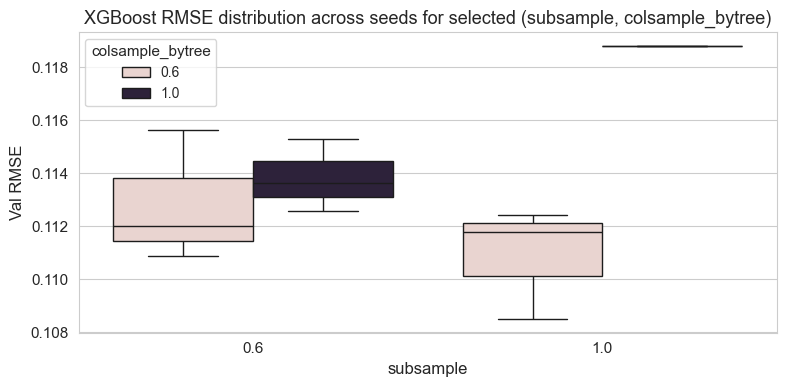

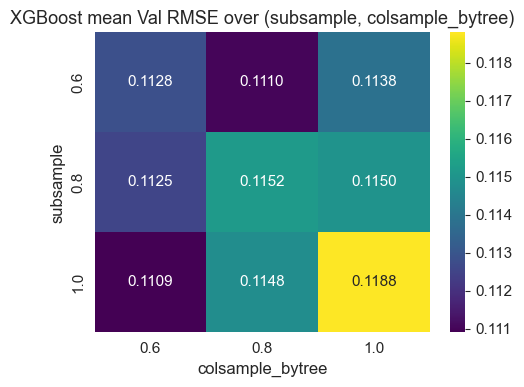

CatBoost bagging_temperature summary:
   param_value  rmse_val_mean  rmse_val_std  rmse_train_mean  rmse_train_std  \
0          0.0        0.10955      0.000933         0.076068         0.00074   
1          0.5        0.10955      0.000933         0.076068         0.00074   
2          1.0        0.10955      0.000933         0.076068         0.00074   
3          2.0        0.10955      0.000933         0.076068         0.00074   
4          5.0        0.10955      0.000933         0.076068         0.00074   

   train_time_mean  train_time_std  
0         0.533691        0.217988  
1         0.330201        0.009804  
2         0.318890        0.029531  
3         0.323514        0.016253  
4         0.446868        0.170437  


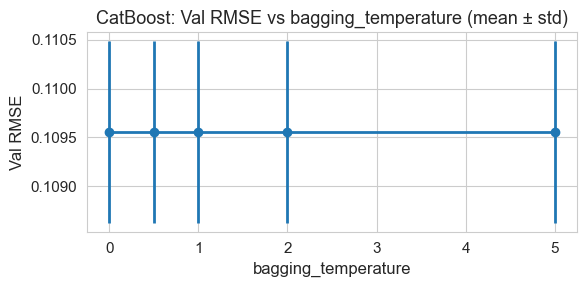

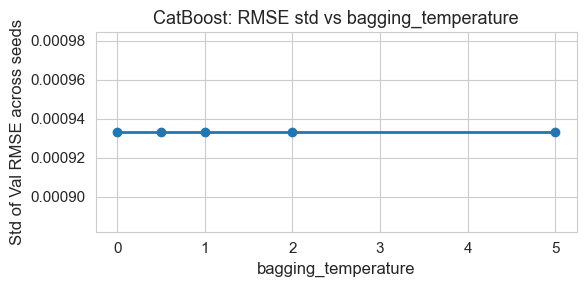

In [24]:
# Experiment Group 2 — Sampling & Randomness
# XGBoost: subsample x colsample_bytree grid
subsample_vals = [0.6, 0.8, 1.0]
colsample_vals = [0.6, 0.8, 1.0]

import time

def run_xgb_grid(subsample_vals, colsample_vals, base_params=None, seeds=SEEDS):
    if base_params is None:
        base_params = dict(n_estimators=200, learning_rate=0.1, max_depth=5, objective='reg:squarederror', tree_method='hist', verbosity=0)
    rows = []
    for subs in subsample_vals:
        for cs in colsample_vals:
            for seed in seeds:
                p = base_params.copy()
                p['subsample'] = subs
                p['colsample_bytree'] = cs
                p['random_state'] = seed
                model = xgb.XGBRegressor(**p)
                t0 = time.time()
                model.fit(X_train, y_train)
                t1 = time.time()
                tt = t1 - t0
                y_pred_val = model.predict(X_val)
                rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
                rows.append({'subsample': subs, 'colsample_bytree': cs, 'seed': seed, 'rmse_val': rmse_val, 'train_time_sec': tt})
    df = pd.DataFrame(rows)
    pivot_mean = df.groupby(['subsample','colsample_bytree'])['rmse_val'].mean().unstack()
    pivot_std = df.groupby(['subsample','colsample_bytree'])['rmse_val'].std().unstack()
    return df, pivot_mean, pivot_std

xgb_grid_df, xgb_grid_mean, xgb_grid_std = run_xgb_grid(subsample_vals, colsample_vals)
xgb_grid_df.to_csv('../assets/experiments/xgb_subsample_colsample_runs.csv', index=False)
print('XGBoost grid done. Mean RMSE pivot:')
print(xgb_grid_mean)

# Boxplot for selected configurations
plt.figure(figsize=(8,4))
sel = xgb_grid_df[(xgb_grid_df['subsample'].isin([0.6,1.0])) & (xgb_grid_df['colsample_bytree'].isin([0.6,1.0]))]
sns.boxplot(x='subsample', y='rmse_val', hue='colsample_bytree', data=sel)
plt.title('XGBoost RMSE distribution across seeds for selected (subsample, colsample_bytree)')
plt.xlabel('subsample')
plt.ylabel('Val RMSE')
plt.tight_layout()
plt.savefig('../assets/experiments/plot_xgb_subsample_colsample_box.png', dpi=200)
plt.show()

# Heatmap of mean RMSE
plt.figure(figsize=(5,4))
sns.heatmap(xgb_grid_mean, annot=True, fmt='.4f', cmap='viridis')
plt.title('XGBoost mean Val RMSE over (subsample, colsample_bytree)')
plt.tight_layout()
plt.savefig('../assets/experiments/plot_xgb_subsample_colsample_heatmap.png', dpi=200)
plt.show()

# CatBoost: bagging_temperature sweep
bagging_vals = [0, 0.5, 1, 2, 5]
cat_bag_df, cat_bag_summary = run_cat_param_sweep('bagging_temperature', bagging_vals)
cat_bag_df.to_csv('../assets/experiments/cat_bagging_runs.csv', index=False)
cat_bag_summary.to_csv('../assets/experiments/cat_bagging_summary.csv', index=False)
print('CatBoost bagging_temperature summary:')
print(cat_bag_summary)

# Plot CatBoost bagging results
plt.figure(figsize=(6,3))
plt.errorbar(cat_bag_summary['param_value'], cat_bag_summary['rmse_val_mean'], yerr=cat_bag_summary['rmse_val_std'], marker='o')
plt.xlabel('bagging_temperature')
plt.ylabel('Val RMSE')
plt.title('CatBoost: Val RMSE vs bagging_temperature (mean ± std)')
plt.tight_layout()
plt.savefig('../assets/experiments/plot_cat_bagging_rmse.png', dpi=200)
plt.show()

plt.figure(figsize=(6,3))
plt.plot(cat_bag_summary['param_value'], cat_bag_summary['rmse_val_std'], marker='o')
plt.xlabel('bagging_temperature')
plt.ylabel('Std of Val RMSE across seeds')
plt.title('CatBoost: RMSE std vs bagging_temperature')
plt.tight_layout()
plt.savefig('../assets/experiments/plot_cat_bagging_rmse_std.png', dpi=200)
plt.show()


In [25]:
# Experiment Group 1 — Regularization (added cell)
# XGBoost: reg_alpha sweep
reg_alpha_vals = [0, 0.01, 0.1, 0.5, 1.0]
xgb_alpha_df_rows = []
for val in reg_alpha_vals:
    for seed in SEEDS:
        p = dict(n_estimators=200, learning_rate=0.1, max_depth=5, objective='reg:squarederror', tree_method='hist', verbosity=0, reg_alpha=val, random_state=seed)
        m = xgb.XGBRegressor(**p)
        t0 = time.time()
        m.fit(X_train, y_train)
        t1 = time.time()
        tt = t1 - t0
        y_pred_train = m.predict(X_train)
        y_pred_val = m.predict(X_val)
        rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
        rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
        stats = parse_xgb_trees(m)
        xgb_alpha_df_rows.append({'param_value': val, 'seed': seed, 'rmse_train': rmse_train, 'rmse_val': rmse_val, 'train_time_sec': tt, **stats})

xgb_alpha_df = pd.DataFrame(xgb_alpha_df_rows)
xgb_alpha_summary = xgb_alpha_df.groupby('param_value').agg({'rmse_val':['mean','std'],'rmse_train':['mean','std'],'train_time_sec':['mean','std'],'num_features_used':'mean','num_leaves':'mean','num_nodes':'mean'}).reset_index()
xgb_alpha_summary.columns = ['param_value','rmse_val_mean','rmse_val_std','rmse_train_mean','rmse_train_std','train_time_mean','train_time_std','num_features_used','num_leaves','num_nodes']
xgb_alpha_summary['gen_gap'] = xgb_alpha_summary['rmse_train_mean'] - xgb_alpha_summary['rmse_val_mean']

xgb_alpha_df.to_csv('../assets/experiments/xgb_reg_alpha_runs.csv', index=False)
xgb_alpha_summary.to_csv('../assets/experiments/xgb_reg_alpha_summary.csv', index=False)
print('XGBoost reg_alpha summary:')
print(xgb_alpha_summary)

# XGBoost: reg_lambda sweep (fix reg_alpha=0)
reg_lambda_vals = [0.1, 1, 5, 10]
base = dict(n_estimators=200, learning_rate=0.1, max_depth=5, objective='reg:squarederror', tree_method='hist', verbosity=0, reg_alpha=0)
xgb_lambda_df_rows = []
for val in reg_lambda_vals:
    for seed in SEEDS:
        p = base.copy()
        p['reg_lambda'] = val
        p['random_state'] = seed
        m = xgb.XGBRegressor(**p)
        t0 = time.time()
        m.fit(X_train, y_train)
        t1 = time.time()
        tt = t1 - t0
        y_pred_train = m.predict(X_train)
        y_pred_val = m.predict(X_val)
        rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
        rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
        stats = parse_xgb_trees(m)
        xgb_lambda_df_rows.append({'param_value': val, 'seed': seed, 'rmse_train': rmse_train, 'rmse_val': rmse_val, 'train_time_sec': tt, **stats})

xgb_lambda_df = pd.DataFrame(xgb_lambda_df_rows)
xgb_lambda_summary = xgb_lambda_df.groupby('param_value').agg({'rmse_val':['mean','std'],'rmse_train':['mean','std'],'train_time_sec':['mean','std'],'num_features_used':'mean','num_leaves':'mean','num_nodes':'mean'}).reset_index()
xgb_lambda_summary.columns = ['param_value','rmse_val_mean','rmse_val_std','rmse_train_mean','rmse_train_std','train_time_mean','train_time_std','num_features_used','num_leaves','num_nodes']
xgb_lambda_df.to_csv('../assets/experiments/xgb_reg_lambda_runs.csv', index=False)
xgb_lambda_summary.to_csv('../assets/experiments/xgb_reg_lambda_summary.csv', index=False)
print('\nXGBoost reg_lambda summary:')
print(xgb_lambda_summary)

# CatBoost: l2_leaf_reg sweep
cat_l2_vals = [1, 3, 5, 10, 20]
cat_l2_df_rows = []
for val in cat_l2_vals:
    for seed in SEEDS:
        p = dict(iterations=200, learning_rate=0.1, depth=5, verbose=False, allow_writing_files=False, l2_leaf_reg=val, random_seed=seed)
        m = CatBoostRegressor(**p)
        t0 = time.time()
        m.fit(X_train, y_train)
        t1 = time.time()
        tt = t1 - t0
        y_pred_train = m.predict(X_train)
        y_pred_val = m.predict(X_val)
        rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
        rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
        stats = catboost_tree_stats(m)
        cat_l2_df_rows.append({'param_value': val, 'seed': seed, 'rmse_train': rmse_train, 'rmse_val': rmse_val, 'train_time_sec': tt, **stats})

cat_l2_df = pd.DataFrame(cat_l2_df_rows)
cat_l2_summary = cat_l2_df.groupby('param_value').agg({'rmse_val':['mean','std'],'rmse_train':['mean','std'],'train_time_sec':['mean','std']}).reset_index()
cat_l2_summary.columns = ['param_value','rmse_val_mean','rmse_val_std','rmse_train_mean','rmse_train_std','train_time_mean','train_time_std']
cat_l2_df.to_csv('../assets/experiments/cat_l2_runs.csv', index=False)
cat_l2_summary.to_csv('../assets/experiments/cat_l2_summary.csv', index=False)
print('\nCatBoost l2_leaf_reg summary:')
print(cat_l2_summary)

XGBoost reg_alpha summary:
   param_value  rmse_val_mean  rmse_val_std  rmse_train_mean  rmse_train_std  \
0         0.00       0.118800           0.0         0.029487             0.0   
1         0.01       0.117134           0.0         0.031119             0.0   
2         0.10       0.118962           0.0         0.029678             0.0   
3         0.50       0.117205           0.0         0.041239             0.0   
4         1.00       0.116580           0.0         0.055397             0.0   

   train_time_mean  train_time_std  num_features_used  num_leaves  num_nodes  \
0         0.491942        0.197804               77.0      5014.0     9828.0   
1         0.231992        0.038840               77.0      4933.0     9666.0   
2         0.266091        0.034563               75.0      5508.0    10816.0   
3         0.277171        0.024841               75.0      5004.0     9808.0   
4         0.689732        0.342470               74.0      3856.0     7512.0   

    gen_gap

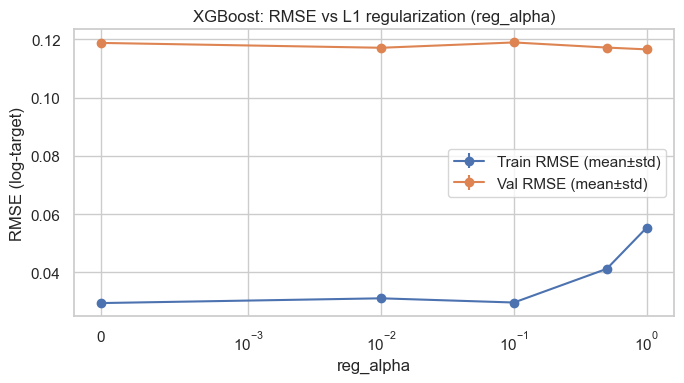

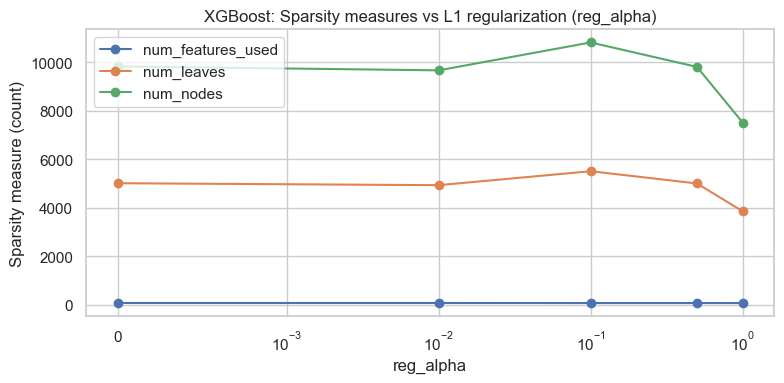

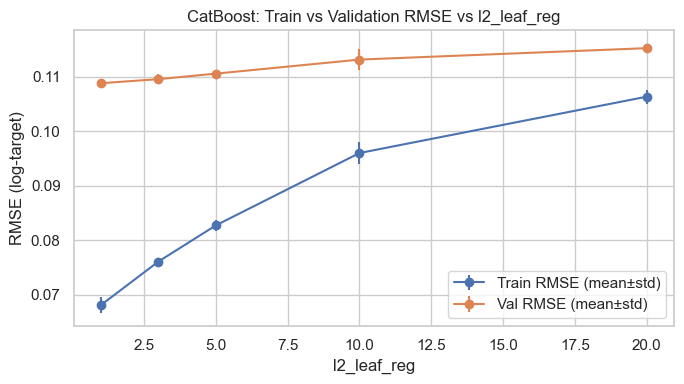

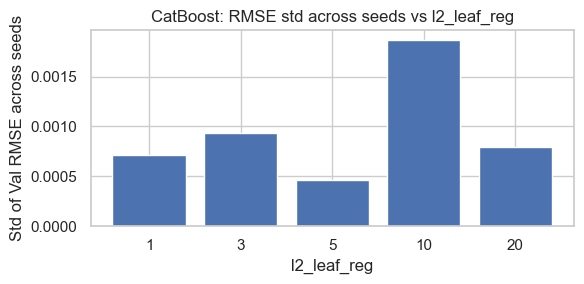

Group 1 plots saved to ../assets/experiments/


In [26]:
# Plotting Group 1 results — Regularization
sns.set(style='whitegrid')

# XGBoost: RMSE (train & val) vs reg_alpha
plt.figure(figsize=(7,4))
plt.errorbar(x=xgb_alpha_summary['param_value'], y=xgb_alpha_summary['rmse_train_mean'], yerr=xgb_alpha_summary['rmse_train_std'], label='Train RMSE (mean±std)', marker='o')
plt.errorbar(x=xgb_alpha_summary['param_value'], y=xgb_alpha_summary['rmse_val_mean'], yerr=xgb_alpha_summary['rmse_val_std'], label='Val RMSE (mean±std)', marker='o')
plt.xscale('symlog', linthresh=1e-3)
plt.xlabel('reg_alpha')
plt.ylabel('RMSE (log-target)')
plt.title('XGBoost: RMSE vs L1 regularization (reg_alpha)')
plt.legend()
plt.tight_layout()
plt.savefig('../assets/experiments/plot_xgb_reg_alpha_rmse.png', dpi=200)
plt.show()

# XGBoost: Sparsity measures vs reg_alpha
plt.figure(figsize=(8,4))
feat_mean = xgb_alpha_df.groupby('param_value')['num_features_used'].mean().reindex(xgb_alpha_summary['param_value']).values
leaves_mean = xgb_alpha_df.groupby('param_value')['num_leaves'].mean().reindex(xgb_alpha_summary['param_value']).values
nodes_mean = xgb_alpha_df.groupby('param_value')['num_nodes'].mean().reindex(xgb_alpha_summary['param_value']).values
plt.plot(xgb_alpha_summary['param_value'], feat_mean, marker='o', label='num_features_used')
plt.plot(xgb_alpha_summary['param_value'], leaves_mean, marker='o', label='num_leaves')
plt.plot(xgb_alpha_summary['param_value'], nodes_mean, marker='o', label='num_nodes')
plt.xscale('symlog', linthresh=1e-3)
plt.xlabel('reg_alpha')
plt.ylabel('Sparsity measure (count)')
plt.title('XGBoost: Sparsity measures vs L1 regularization (reg_alpha)')
plt.legend()
plt.tight_layout()
plt.savefig('../assets/experiments/plot_xgb_reg_alpha_sparsity.png', dpi=200)
plt.show()

# CatBoost: Train vs Val RMSE vs l2_leaf_reg
plt.figure(figsize=(7,4))
plt.errorbar(x=cat_l2_summary['param_value'], y=cat_l2_summary['rmse_train_mean'], yerr=cat_l2_summary['rmse_train_std'], label='Train RMSE (mean±std)', marker='o')
plt.errorbar(x=cat_l2_summary['param_value'], y=cat_l2_summary['rmse_val_mean'], yerr=cat_l2_summary['rmse_val_std'], label='Val RMSE (mean±std)', marker='o')
plt.xlabel('l2_leaf_reg')
plt.ylabel('RMSE (log-target)')
plt.title('CatBoost: Train vs Validation RMSE vs l2_leaf_reg')
plt.legend()
plt.tight_layout()
plt.savefig('../assets/experiments/plot_cat_l2_rmse.png', dpi=200)
plt.show()

# CatBoost: Std deviation of RMSE vs l2_leaf_reg
plt.figure(figsize=(6,3))
plt.bar(cat_l2_summary['param_value'].astype(str), cat_l2_summary['rmse_val_std'])
plt.xlabel('l2_leaf_reg')
plt.ylabel('Std of Val RMSE across seeds')
plt.title('CatBoost: RMSE std across seeds vs l2_leaf_reg')
plt.tight_layout()
plt.savefig('../assets/experiments/plot_cat_l2_rmse_std.png', dpi=200)
plt.show()

print('Group 1 plots saved to ../assets/experiments/')

In [27]:
# Train optimal models on combined train+validation set, evaluate on test
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

print("="*70)
print("FINAL MODEL EVALUATION ON TEST SET")
print("="*70)

# Optimal XGBoost (based on learning rate sensitivity)
xgb_final = xgb.XGBRegressor(
    learning_rate=0.1,
    max_depth=5,
    n_estimators=100,
    subsample=0.9,
    random_state=42,
    verbosity=0
)
xgb_final.fit(X_train_full, y_train_full)
y_pred_xgb_test = xgb_final.predict(X_test)

xgb_rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_xgb_test))
xgb_mae_orig = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_xgb_test))
xgb_r2 = r2_score(y_test, y_pred_xgb_test)

# Optimal CatBoost
cat_final = CatBoostRegressor(
    learning_rate=0.1,
    depth=5,
    iterations=100,
    l2_leaf_reg=1.0,
    random_state=42,
    verbose=0,
    allow_writing_files=False
)
cat_final.fit(X_train_full, y_train_full, cat_features=categorical_features if categorical_features else None)
y_pred_cat_test = cat_final.predict(X_test)

cat_rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_cat_test))
cat_mae_orig = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_cat_test))
cat_r2 = r2_score(y_test, y_pred_cat_test)

print(f"\nXGBoost Performance:")
print(f"  RMSE (log-transformed):  {xgb_rmse_log:.6f}")
print(f"  MAE (original scale):    ${xgb_mae_orig:,.2f}")
print(f"  R² Score:                {xgb_r2:.6f}")

print(f"\nCatBoost Performance:")
print(f"  RMSE (log-transformed):  {cat_rmse_log:.6f}")
print(f"  MAE (original scale):    ${cat_mae_orig:,.2f}")
print(f"  R² Score:                {cat_r2:.6f}")

print(f"\nRelative Performance:")
print(f"  RMSE improvement:        {((xgb_rmse_log - cat_rmse_log) / xgb_rmse_log * 100):.2f}% (CatBoost better)")
print(f"  MAE improvement:         {((xgb_mae_orig - cat_mae_orig) / xgb_mae_orig * 100):.2f}% (CatBoost better)")
print(f"  R² improvement:          {((cat_r2 - xgb_r2) / abs(xgb_r2) * 100):.2f}% (CatBoost better)")

FINAL MODEL EVALUATION ON TEST SET

XGBoost Performance:
  RMSE (log-transformed):  0.106311
  MAE (original scale):    $14,214.10
  R² Score:                0.938917

CatBoost Performance:
  RMSE (log-transformed):  0.110707
  MAE (original scale):    $15,345.45
  R² Score:                0.933762

Relative Performance:
  RMSE improvement:        -4.13% (CatBoost better)
  MAE improvement:         -7.96% (CatBoost better)
  R² improvement:          -0.55% (CatBoost better)


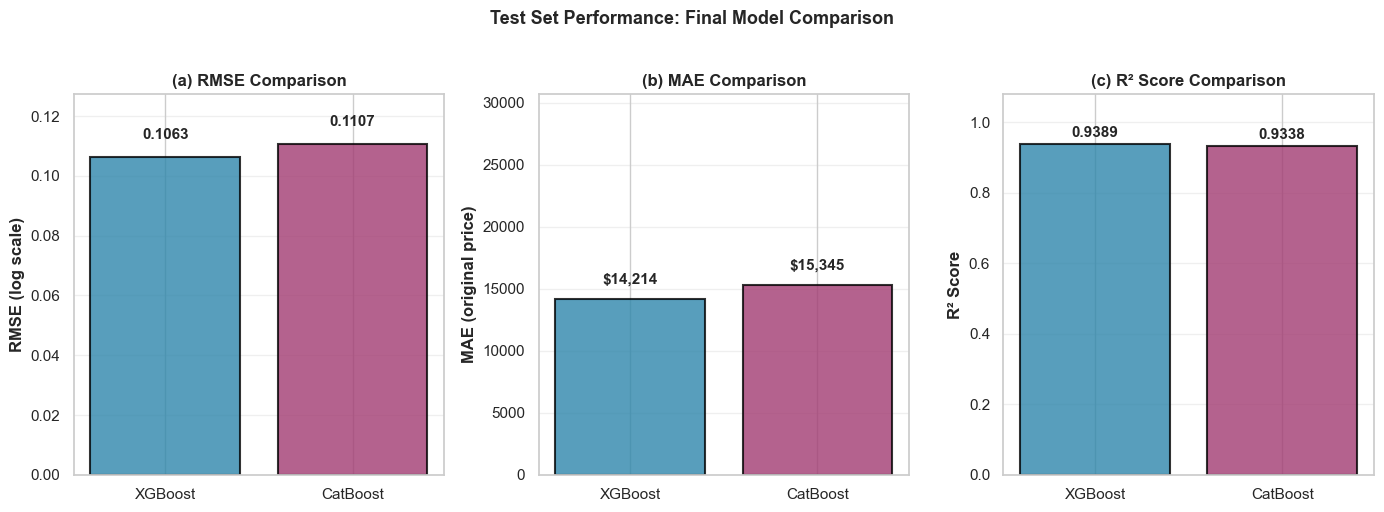

In [33]:
# Create comparison bar chart
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

models = ['XGBoost', 'CatBoost']
colors = ['#2E86AB', '#A23B72']

# RMSE Comparison
rmse_vals = [xgb_rmse_log, cat_rmse_log]
bars1 = axes[0].bar(models, rmse_vals, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('RMSE (log scale)', fontsize=12, fontweight='bold')
axes[0].set_title('(a) RMSE Comparison', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, max(rmse_vals) * 1.15)
for i, (bar, val) in enumerate(zip(bars1, rmse_vals)):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.005, f'{val:.4f}', 
                ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# MAE Comparison
mae_vals = [xgb_mae_orig, cat_mae_orig]
bars2 = axes[1].bar(models, mae_vals, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('MAE (original price)', fontsize=12, fontweight='bold')
axes[1].set_title('(b) MAE Comparison', fontsize=12, fontweight='bold')
axes[1].set_ylim(0, max(mae_vals) * 2)
for i, (bar, val) in enumerate(zip(bars2, mae_vals)):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 1000, f'${val:,.0f}', 
                ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

# R² Comparison
r2_vals = [xgb_r2, cat_r2]
bars3 = axes[2].bar(models, r2_vals, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
axes[2].set_ylabel('R² Score', fontsize=12, fontweight='bold')
axes[2].set_title('(c) R² Score Comparison', fontsize=12, fontweight='bold')
axes[2].set_ylim(0, max(r2_vals) * 1.15)
for i, (bar, val) in enumerate(zip(bars3, r2_vals)):
    axes[2].text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.4f}', 
                ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle('Test Set Performance: Final Model Comparison', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [34]:
# Create a summary table
summary_data = {
    'Metric': ['RMSE (log-transformed)', 'MAE (original scale)', 'R² Score'],
    'XGBoost': [f'{xgb_rmse_log:.6f}', f'${xgb_mae_orig:,.2f}', f'{xgb_r2:.6f}'],
    'CatBoost': [f'{cat_rmse_log:.6f}', f'${cat_mae_orig:,.2f}', f'{cat_r2:.6f}'],
    'CatBoost Improvement': [
        f'{((xgb_rmse_log - cat_rmse_log) / xgb_rmse_log * 100):.2f}%',
        f'{((xgb_mae_orig - cat_mae_orig) / xgb_mae_orig * 100):.2f}%',
        f'{((cat_r2 - xgb_r2) / abs(xgb_r2) * 100):.2f}%'
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*80)
print("TEST SET PERFORMANCE SUMMARY")
print("="*80)
print(summary_df.to_string(index=False))
print("="*80)


TEST SET PERFORMANCE SUMMARY
                Metric    XGBoost   CatBoost CatBoost Improvement
RMSE (log-transformed)   0.106311   0.110707               -4.13%
  MAE (original scale) $14,214.10 $15,345.45               -7.96%
              R² Score   0.938917   0.933762               -0.55%


In [35]:
import time
import pandas as pd

print("\n" + "="*80)
print("COMPUTATIONAL EFFICIENCY BENCHMARK: Training & Inference Time")
print("="*80)

# Use combined training set (train + validation) for fair comparison
X_train_bench = pd.concat([X_train, X_val])
y_train_bench = pd.concat([y_train, y_val])

# Configuration for fair comparison
benchmark_config = {
    'learning_rate': 0.1,
    'max_depth': 5,
    'n_estimators': 100,
    'random_state': 42
}

print(f"\nBenchmark Configuration:")
print(f"  Training samples: {X_train_bench.shape[0]}")
print(f"  Test samples: {X_test.shape[0]}")
print(f"  Features: {X_train_bench.shape[1]}")
print(f"  Hyperparameters: {benchmark_config}")

# Storage for timing results
timing_results = {
    'Model': ['XGBoost', 'CatBoost'],
    'Training Time (s)': [],
    'Inference Time - Avg (s)': [],
    'Inference Time - Std (s)': [],
    'Speedup Factor': []
}

# ============================================================================
# XGBOOST BENCHMARKING
# ============================================================================
print("\n" + "-"*80)
print("XGBoost Benchmarking")
print("-"*80)

# Training time measurement
start_train = time.perf_counter()
xgb_bench = xgb.XGBRegressor(
    learning_rate=benchmark_config['learning_rate'],
    max_depth=benchmark_config['max_depth'],
    n_estimators=benchmark_config['n_estimators'],
    subsample=0.9,
    random_state=benchmark_config['random_state'],
    verbosity=0
)
xgb_bench.fit(X_train_bench, y_train_bench)
end_train = time.perf_counter()
xgb_train_time = end_train - start_train

print(f"Model initialization + training: {xgb_train_time:.6f} seconds")

# Inference time measurement (10 runs)
n_inference_runs = 10
xgb_inference_times = []

for run in range(n_inference_runs):
    start_infer = time.perf_counter()
    _ = xgb_bench.predict(X_test)
    end_infer = time.perf_counter()
    xgb_inference_times.append(end_infer - start_infer)

xgb_infer_mean = np.mean(xgb_inference_times)
xgb_infer_std = np.std(xgb_inference_times)

print(f"Inference time (averaged over {n_inference_runs} runs):")
print(f"  Mean: {xgb_infer_mean:.6f} seconds")
print(f"  Std:  {xgb_infer_std:.6f} seconds")
print(f"  Min:  {np.min(xgb_inference_times):.6f} seconds")
print(f"  Max:  {np.max(xgb_inference_times):.6f} seconds")

timing_results['Training Time (s)'].append(xgb_train_time)
timing_results['Inference Time - Avg (s)'].append(xgb_infer_mean)
timing_results['Inference Time - Std (s)'].append(xgb_infer_std)

# ============================================================================
# CATBOOST BENCHMARKING
# ============================================================================
print("\n" + "-"*80)
print("CatBoost Benchmarking")
print("-"*80)

# Training time measurement
start_train = time.perf_counter()
cat_bench = CatBoostRegressor(
    learning_rate=benchmark_config['learning_rate'],
    depth=benchmark_config['max_depth'],
    iterations=benchmark_config['n_estimators'],
    l2_leaf_reg=1.0,
    random_state=benchmark_config['random_state'],
    verbose=0,
    allow_writing_files=False
)
cat_bench.fit(
    X_train_bench, y_train_bench,
    cat_features=categorical_features if categorical_features else None
)
end_train = time.perf_counter()
cat_train_time = end_train - start_train

print(f"Model initialization + training: {cat_train_time:.6f} seconds")

# Inference time measurement (10 runs)
cat_inference_times = []

for run in range(n_inference_runs):
    start_infer = time.perf_counter()
    _ = cat_bench.predict(X_test)
    end_infer = time.perf_counter()
    cat_inference_times.append(end_infer - start_infer)

cat_infer_mean = np.mean(cat_inference_times)
cat_infer_std = np.std(cat_inference_times)

print(f"Inference time (averaged over {n_inference_runs} runs):")
print(f"  Mean: {cat_infer_mean:.6f} seconds")
print(f"  Std:  {cat_infer_std:.6f} seconds")
print(f"  Min:  {np.min(cat_inference_times):.6f} seconds")
print(f"  Max:  {np.max(cat_inference_times):.6f} seconds")

timing_results['Training Time (s)'].append(cat_train_time)
timing_results['Inference Time - Avg (s)'].append(cat_infer_mean)
timing_results['Inference Time - Std (s)'].append(cat_infer_std)

# ============================================================================
# RESULTS SUMMARY
# ============================================================================
# Calculate speedup factors
xgb_speedup = xgb_infer_mean / cat_infer_mean  # lower is better for speedup
cat_speedup = xgb_train_time / cat_train_time   # lower is better

timing_results['Speedup Factor'].append(f"Training: {cat_speedup:.2f}x")
timing_results['Speedup Factor'].append(f"Inference: {xgb_speedup:.2f}x")

# Create summary DataFrame
timing_df = pd.DataFrame(timing_results)

print("\n" + "="*80)
print("BENCHMARK RESULTS SUMMARY")
print("="*80)
print(timing_df.to_string(index=False))

print(f"\n{'Detailed Analysis:':^80}")
print("-" * 80)
print(f"Training Time Comparison:")
print(f"  XGBoost:  {xgb_train_time:.6f} s")
print(f"  CatBoost: {cat_train_time:.6f} s")
print(f"  Ratio (CatBoost / XGBoost): {cat_train_time / xgb_train_time:.2f}x")

print(f"\nInference Time Comparison (mean ± std):")
print(f"  XGBoost:  {xgb_infer_mean:.6f} ± {xgb_infer_std:.6f} s")
print(f"  CatBoost: {cat_infer_mean:.6f} ± {cat_infer_std:.6f} s")
print(f"  Ratio (XGBoost / CatBoost): {xgb_infer_mean / cat_infer_mean:.2f}x")

print(f"\nTotal Runtime (Training + Single Inference):")
print(f"  XGBoost:  {xgb_train_time + xgb_infer_mean:.6f} s")
print(f"  CatBoost: {cat_train_time + cat_infer_mean:.6f} s")

print("="*80)


COMPUTATIONAL EFFICIENCY BENCHMARK: Training & Inference Time

Benchmark Configuration:
  Training samples: 2344
  Test samples: 586
  Features: 81
  Hyperparameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'random_state': 42}

--------------------------------------------------------------------------------
XGBoost Benchmarking
--------------------------------------------------------------------------------
Model initialization + training: 0.138535 seconds
Inference time (averaged over 10 runs):
  Mean: 0.007031 seconds
  Std:  0.000814 seconds
  Min:  0.006194 seconds
  Max:  0.008551 seconds

--------------------------------------------------------------------------------
CatBoost Benchmarking
--------------------------------------------------------------------------------
Model initialization + training: 3.331565 seconds
Inference time (averaged over 10 runs):
  Mean: 0.008736 seconds
  Std:  0.000521 seconds
  Min:  0.008300 seconds
  Max:  0.010214 seconds

BE